# Assignment 01 - Iris Species Classification using Spark MLlib (Using Hadoop Cluster)

### Matrix Number: P166246
### Author: Muzaffar Izamuddin bin Daud

---

## 1. Introduction
This notebook demonstrates a end-to-end Machine Learning workflow using Spark MLlib to classify Iris flower species. The primary goal is to leverage distributed data processing and model training using Spark MLlib to train, tune, and evaluate multiple classification models on the classic Iris dataset. Using the tuned hyperparameters, this notebook then runs a local machine learning model to enable classification of different petal and sepal dimensions locally. This report concludes by comparing each model tested in terms of both accuracy as well as visualisation of decision boundaries.

This notebook utilizes Pyspark or Apache Spark 3.x on HDP 2.6.5 system. YARN (Hadoop Cluster) is utilized as a resource manager while on colab both scikit-learn and pyspark was utilized in the prediction portion of this assignment. For running pyspark on Hadoop HDFS is used as the storage for running scripts while GitHub is utilized as storage for reproducibility. Therefore this notebook is developed on both Hortonworks Data Platform (HDP) and the results were later organised and visualised in Google Colab for reporting purposes.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/P166246_Iris_Spark.ipynb)

## 2. 🎯 Problem Statement

This project aims to develop and evaluate various machine learning models for classifying Iris flower species using the classic Iris dataset. The primary challenge is to identify the most accurate and robust classification algorithm within a distributed computing environment (Apache Spark with Hadoop YARN), while also ensuring the model's performance on local, smaller-scale predictions. The models will be trained, tuned, and compared based on key performance metrics such as accuracy, F1-score, precision, and recall. We will also look at the model complexity and if the same amount of accuracy can be achieved using a simpler model that does not require as much computing resources.

After implementing and optimizing five classification algorithms (Logistic Regression, Decision Tree, Random Forest, Naive Bayes, and Neural Network) using Spark MLlib, the study will also evaluate and compare the performance of these models on both training and test datasets. We will utilize confusion matrices and ROC curves, to understand each model's strengths and weaknesses. Although the study focused on the use of Spark MLlib library, we will also utilize `scikit-learn` and `pyspark` as a supplementary library for demo purposes. Finally we will visualize boundaries using the parameters chosen in hyperparameter tuning to understand the differences between models. This study attempts to use a 2D plot seperately on both sepal and petal dimensions to help us understand how each model works in classifying each of these flowers.


scikit-learn as a supplementary comparison/demo, not as part of the main model pipeline
- your main model pipeline is still Spark MLlib, no?

Because some of the python script ran inside hadoop, the output of those hadoop environement will be shown using images saved in github. We now initialize a function to be able to display the images:


In [ ]:
#this cell is a function for loading github images
import matplotlib.pyplot as plt
from PIL import Image  # <--- Make sure this specific line is present
import requests
from io import BytesIO

def show_github_img(repo_path, size=(15, 10)):
    """Fetches and displays an image with adjustable size."""
    base_url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/main/"
    full_url = base_url + repo_path

    try:
        response = requests.get(full_url)
        img = Image.open(BytesIO(response.content))

        # Set the size here (Width, Height in inches)
        plt.figure(figsize=size)

        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout() # Reduces white space around the image
        plt.show()
    except Exception as e:
        print(f"Error loading image from {full_url}: {e}")

### 2.1 **Iris Dataset Origin**
The Iris dataset is a classic and widely used multivariate dataset introduced by **Ronald Fisher in 1936**. It contains 150 samples of iris flowers, each belonging to one of three species (Iris setosa, Iris versicolor, or Iris virginica), with four features measured from each sample: sepal length, sepal width, petal length, and petal width. This dataset is renowned for its use in pattern recognition and is frequently employed as a benchmark for classification algorithms (Fisher, R. A., 1936). This study uses the dataset to evaluate five machine learning models including Logistic Regression, Decision Trees, Random Forest, Naive Bayes and Neural Network. Figure 1 illustrates the visual differences among the three Iris species:

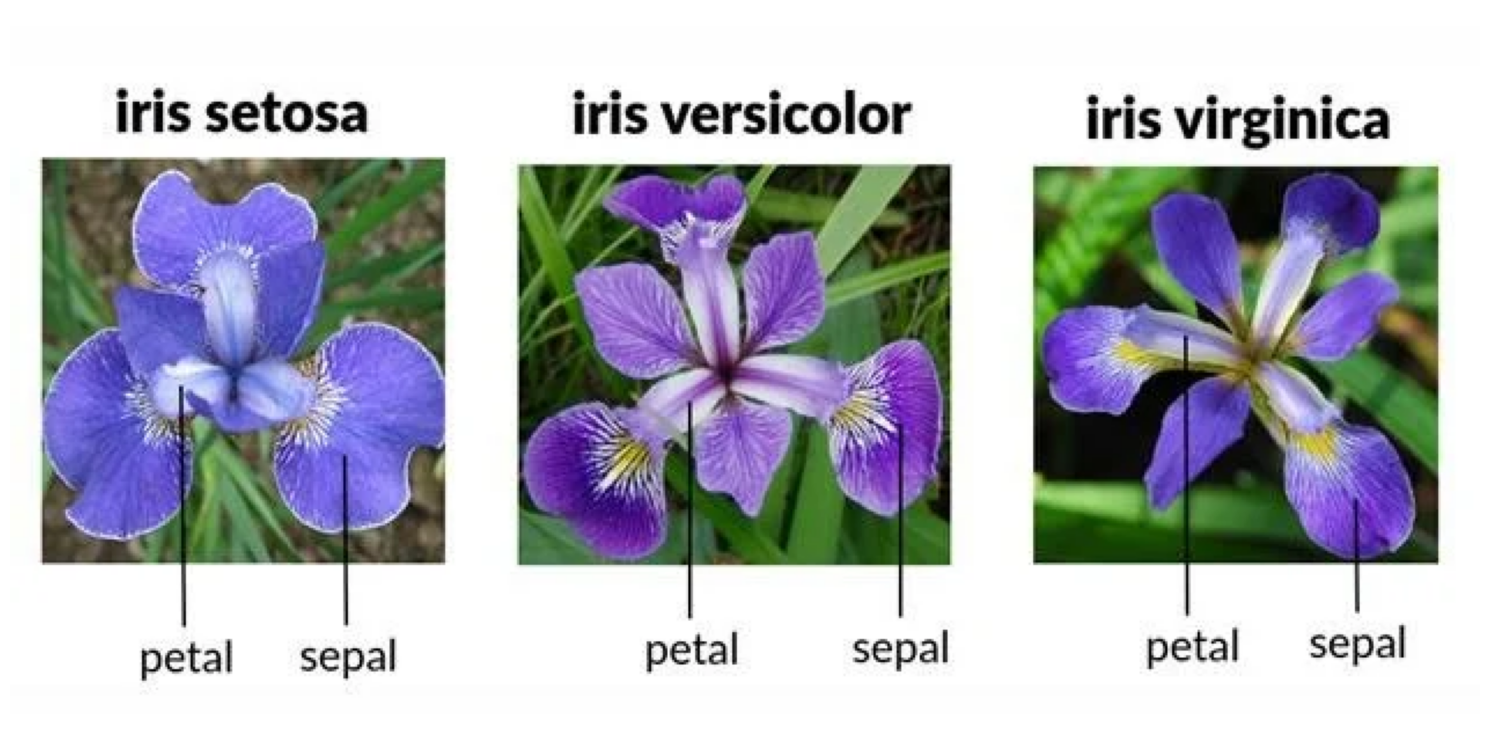

In [ ]:
show_github_img("images/IRIS-flower.JPG")

The first step is to load the `iris.csv` data and save it locally

In [ ]:
import pandas as pd

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

iris_df = pd.read_csv(url, header=None, names=columns).dropna()
iris_df.to_csv('iris.csv', index=False) #save data locally for upload into hadoop
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


The `iris.csv` file is then uploaded to HDFS, and all Spark Python machine learning scripts are executed on Unix through Putty.

In [ ]:
#Function definition cell for loading parquet data (saved from hadoop), extracting probabilities and for visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import requests
import io

def load_parquet_auto(repo_owner, repo_name, folder_path):
    """
    Automatically finds and reads all parquet files in a GitHub folder
    without needing specific part names.
    """
    # 1. Use GitHub API to list files in the directory
    api_url = f"https://api.github.com/repos/{repo_owner}/{repo_name}/contents/{folder_path}"
    response = requests.get(api_url)

    if response.status_code != 200:
        print(f"Error fetching directory list: {response.status_code}")
        return pd.DataFrame()

    # 2. Filter for files ending in .parquet
    files = response.json()
    parquet_urls = [f['download_url'] for f in files if f['name'].endswith('.parquet')]

    if not parquet_urls:
        print("No parquet files found in this folder.")
        return pd.DataFrame()

    # 3. Read and combine all files
    df_list = []
    for url in parquet_urls:
        print(f"Automatically reading: {url.split('/')[-1]}")
        # Download the file content into memory and read with pandas
        resp = requests.get(url)
        df_part = pd.read_parquet(io.BytesIO(resp.content))
        df_list.append(df_part)

    return pd.concat(df_list, ignore_index=True)

def extract_probs(df, col_name='probability'):
    """Extracts raw decimals from Spark probability format."""
    raw_probs = []
    for row in df[col_name]:
        # Handle dictionary format often found in Spark Parquet
        if isinstance(row, dict) and 'values' in row:
            raw_probs.append(row['values'])
        # Handle list/array format
        elif isinstance(row, (list, np.ndarray)):
            raw_probs.append(row)
        else:
            raw_probs.append([0.0, 0.0, 0.0])
    return np.array(raw_probs)

def plot_dual_confusion_matrix(df, classes):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Standardize case to handle 'TRAIN' or 'train'
    df['dataset_type'] = df['dataset_type'].str.upper()

    for i, d_type in enumerate(['TRAIN', 'TEST']):
        subset = df[df['dataset_type'] == d_type]
        if len(subset) > 0:
            cm = confusion_matrix(subset['label'], subset['prediction'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                        xticklabels=classes, yticklabels=classes)
            axes[i].set_title(f'Confusion Matrix ({d_type})')
    plt.show()

def plot_dual_roc(df, classes):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    df['dataset_type'] = df['dataset_type'].str.upper()

    for idx, d_type in enumerate(['TRAIN', 'TEST']):
        subset = df[df['dataset_type'] == d_type]
        if len(subset) > 0:
            y_true_bin = label_binarize(subset['label'], classes=[0, 1, 2])
            y_probs = extract_probs(subset)

            for i in range(len(classes)):
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
                axes[idx].plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')

            axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.2)
            axes[idx].set_title(f'ROC Curve ({d_type})')
            axes[idx].legend(loc="lower right")
    plt.show()

def display_metrics_summary(df):
    df['dataset_type'] = df['dataset_type'].str.upper()
    for d_type in ['TRAIN', 'TEST']:
        subset = df[df['dataset_type'] == d_type]
        if len(subset) > 0:
            report = classification_report(subset['label'], subset['prediction'], output_dict=True)
            print(f"\n--- {d_type} METRICS ---")
            print(f"Accuracy:  {report['accuracy']:.4f}")
            print(f"F1-Score:  {report['macro avg']['f1-score']:.4f}")
            print(f"Precision: {report['macro avg']['precision']:.4f}")
            print(f"Recall:    {report['macro avg']['recall']:.4f}")

## ⚙️ 3. Methodology

### **3.1 Train/Test Split Percentages**
To ensure the model's ability to generalize, and because our dataset is small, the dataset was split using a **70:30 ratio**, favoring more data for training while not having too small a dataset for the test group. The training Set (70%)is used to fit the models and perform hyperparameter tuning via the Hadoop cluster, while the Test Set (30%) is reserved as hold-out set to provide an unbiased evaluation of the final model's performance. Confusion matrices and ROC curves are then plotted as evaluation outputs generated from the test predictions.

The output from the hadoop python script adds a column indicating whether each record belongs to the training or test partition so that plots in colab will match the results achieved in Hadoop. After running the scripts in Hadoop environment, the output dataset has been saved locally in the `Spark_Results` folder. To ensure the project is fully reproducible by others, the spark scripts, jupyter notebook and dataset source has also been uploaded to the [GitHub Repository](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324).

---

### **3.2 Model Implementation & Optimization Strategy**

To identify the most accurate classifier for the Iris dataset and to compare their predictive performance and modelling characteristics, five distinct machine learning models were developed and optimized within the Spark ecosystem. Each model was implemented in a dedicated script to leverage parallelized hyperparameter tuning across the Hadoop cluster.

#### **3.2.1 Implementation Scripts**
The following scripts are used in Hadoop HDP2.6.5. They contain the full pipeline from data ingestion, feature scaling to cross-validation, evaluation for each algorithm as well as a parameter refinement script for logistic regression model. The script also outputs the results in terminal while saving it in HDFS so that we can extract and reuse in Github and Colab. Below are the scripts used in Hadoop:

| Algorithm | Script Filename | Primary Role | Go To Script |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | `logreg_iris.py` | Statistical baseline and probability-based classification. | [Go To Script](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/Spark_python_script/logreg_iris.py) |
| **Logistic Regression Optimize** | `logreg_optimize.py` | A script to refine parameters further by small increments. | [Go To Script](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/Spark_python_script/logreg_optimize.py) |
| **Decision Tree** | `dtree_iris.py` | Rule-based classification for high interpretability. | [Go To Script](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/Spark_python_script/dtree_iris.py) |
| **Random Forest** | `rf_iris.py` | Ensemble method used to reduce variance and prevent overfitting. | [Go To Script](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/Spark_python_script/rf_iris.py) |
| **Naive Bayes** | `nb_iris.py` | Probabilistic classifier based on feature independence. | [Go To Script](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/Spark_python_script/nb_iris.py) |
| **Neural Network (MLP)** | `mlp_iris.py` | Deep learning approach for capturing complex, non-linear patterns. | [Go To Script](https://github.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/blob/main/Spark_python_script/mlp_iris.py) |

---
A specific optimization script, logreg_optimize.py was additionally created for logistic regression as the model took shorter computation times and therefore allow Spark to run more logistic regression models by small increments in parameters. This allowed the logistic regression parameter to be refined further than the original optimization using param grid builder function. 

#### **3.2.2 Optimization Workflow**
For each script, a systematic optimization process was followed to ensure the models reached their peak performance. Grid Search (`ParamGridBuilder`) was used instead of using static parameters, a search grid was defined for each model. For example in logistic regression model multiple `regParam` and `elasticNetParam` values were tested. 3-Fold Cross-Validation technique was used through the Spark `CrossValidator` function where the training dataset was split into three folds, ensuring that the selected hyperparameters were stable and not biased by a single data split.

Continuous features were standardized using `StandardScaler` function. Scaling helps models sensitive to feature magnitude, especially for Logistic Regression and MLP models. F1-score was used to balance precision and recall, while accuracy provides an overall correctness measure.

#### **3.2.3 Grid Builder Parameters and Cross-Validation Strategy**

The optimization process across all models consistently leveraged two key Spark MLlib components to ensure robust and generalizable results namely hyperparameter tuning using ParamGridBuilder. A 3-fold cross-validation technique was chosen due to the relatively small size of the Iris dataset (150 samples) which was made even smaller when splitting out test dataset leaving only 70% or 105 data points for training. 

This approach provides a more stable and less biased estimate of a model's performance on unseen data by splitting the training data into multiple folds. Each fold acts as a validation set once, and the model is trained on the remaining folds. The performance metrics are then averaged across all folds, making the chosen hyperparameters more reliable and preventing overfitting to a single train-test split. The model can then be tested on a test dataset that has already been isolated at the start which removes bias and ensures a robust assessment of the model. The table below shows the hyperparameter evaluated during the gird search.


| Model                  | Parameter              | Values Evaluated                           |
| :--------------------- | :--------------------- | :----------------------------------------- |
| **Logistic Regression**| `regParam`             | `[0.001, 0.002, 0.003]`                    |
|                        | `elasticNetParam`      | `[0.0001, 0.00001, 0.000001]`              |
| **Decision Tree**      | `maxDepth`             | `[5, 7, 10]`                               |
|                        | `impurity`             | `["gini", "entropy"]`                      |
|                        | `minInstancesPerNode`  | `[1]`                                      |
| **Random Forest**      | `numTrees`             | `[5, 10, 15]`                              |
|                        | `maxDepth`             | `[5, 7, 9]`                                |
|                        | `subsamplingRate`      | `[0.8, 0.9, 1.0]`                          |
|                        | `minInstancesPerNode`  | `[5]`                                      |
| **Naive Bayes**        | `smoothing`            | `[0.1, 1.0, 5.0]`                          |
| **Neural Network (MLP)**| `layers`               | `[[4, 5, 4, 3], [4, 8, 3]]`                |
|                        | `stepSize`             | `[0.05, 0.1]`                              |
|                        | `maxIter`              | `[200]`                                    |
|                        | `blockSize`            | `[1]`                                      |

## 4. Models

### 4.1. Logistic Regression
The first model evaluated is logistic regression. Logistic regression uses less computational power than the other models and we can afford to conduct an iterative parameter searching before we actually run using the grid hyperparameter optimization run. The 0.02 regularization and 0 elastic net hyperparameter was the result from logreg_iris.py and this output were used as the initialization for logreg_optimize.py to incrementally change the parameters from that initial value until we get the best result.

Using this framework, regParam and elasticNetParam is incrementally changed based on the training data. The script also calculates accuracy based on the test dataset and displays the result. The optimization is done inside Hadoop by running below code: <br>
spark-submit --master yarn logreg_optimize.py


#### 4.1.1  Script Runs
When running Spark applications, we specify `--master yarn` which directs Spark to utilize **YARN (Yet Another Resource Negotiator)** as its cluster manager. YARN is a core component of the Hadoop ecosystem that is responsible for managing computing resources and scheduling applications across a cluster.

YARN allows Spark to dynamically allocate resources (CPU, memory) across the Hadoop cluster for machine learning tasks. This ensures efficient utilization of hardware and prevents resource contention with other applications. By integrating with YARN, Spark can scale out to handle larger datasets and more complex computations than a standalone Spark setup. Although the iris dataset contains 150 records, we use YARN to showcase that the same workflow can be adapted to larger datasets in the future.

The results from the logreg_optimize.py script are shown below:

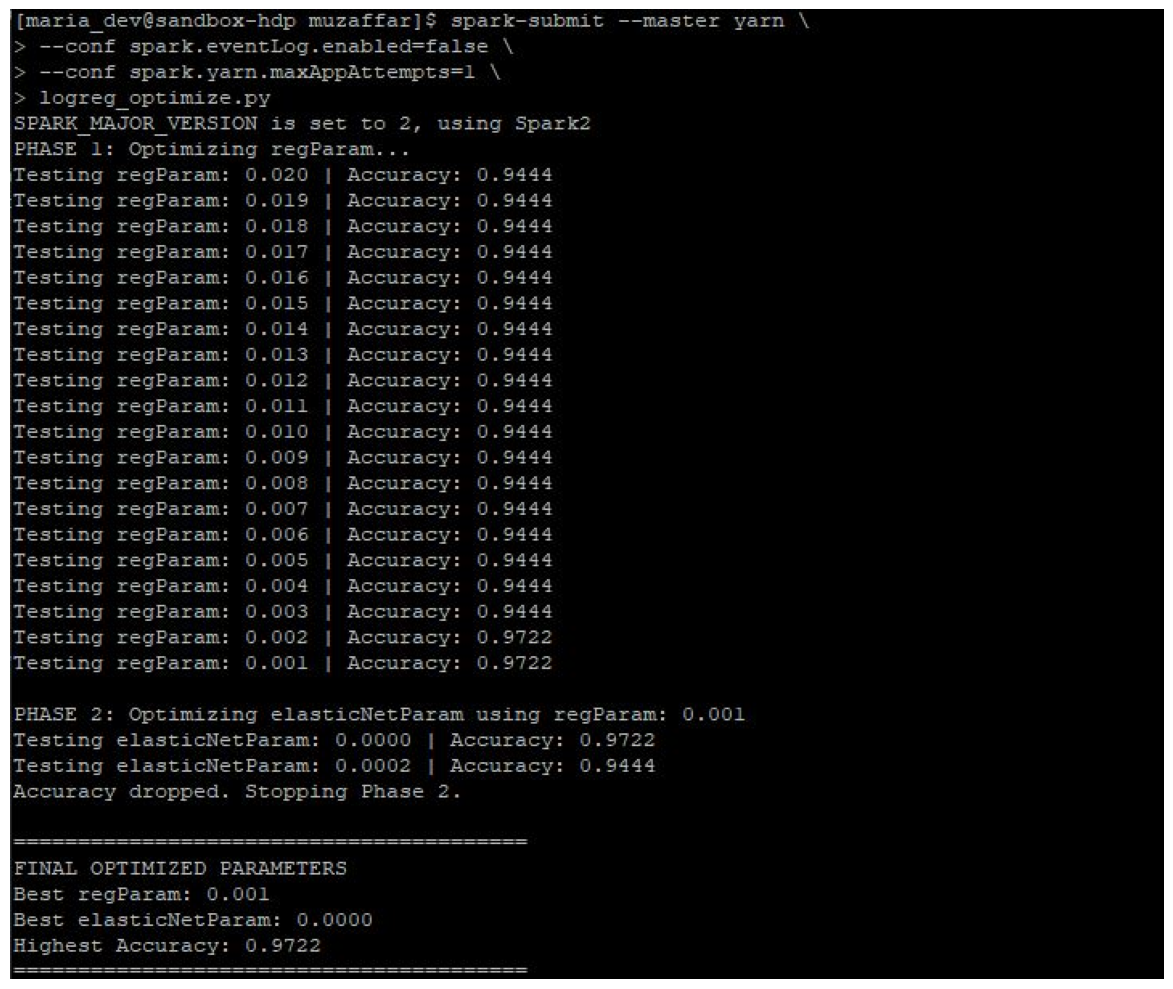

In [ ]:
show_github_img("images/logreg_results_optimize.JPG")

#### ⚙️ 4.1.2 Logistic Regression: Hyperparameter Tuning & Results

After narrowing the search range using logreg_optimize.py, the main logreg_iris.py script can perform a more targeted grid search using Spark's `ParamGridBuilder`. This process systematically evaluated **nine unique parameter combinations** by intersecting two critical hyperparameters namely reg_space and elastic_space. Below is a excerpt from logreg_iris.py which shows the implementation of the grid search

```python
# Implementation of the Grid Search in logreg_iris.py
    reg_space = [0.001,0.002,0.003]
    elastic_space = [0.0001,0.00001,0.000001]      
    paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, reg_space) \
    .addGrid(lr.elasticNetParam, elastic_space) \
    .build()



The best hyperparameters value selected through cross validation were:<br>
Regularization : 0.001<br>
elasticNetParam (L1/L2 Mix) : 0.0001

The results from these parameters already show a 97% accuracy, meaning only 2 flowers out of a 45-sample test set were mispredicted. however it should be noted the test dataset size is very small. <br>
The output from logreg_iris.py executed on Hadoop is shown below.


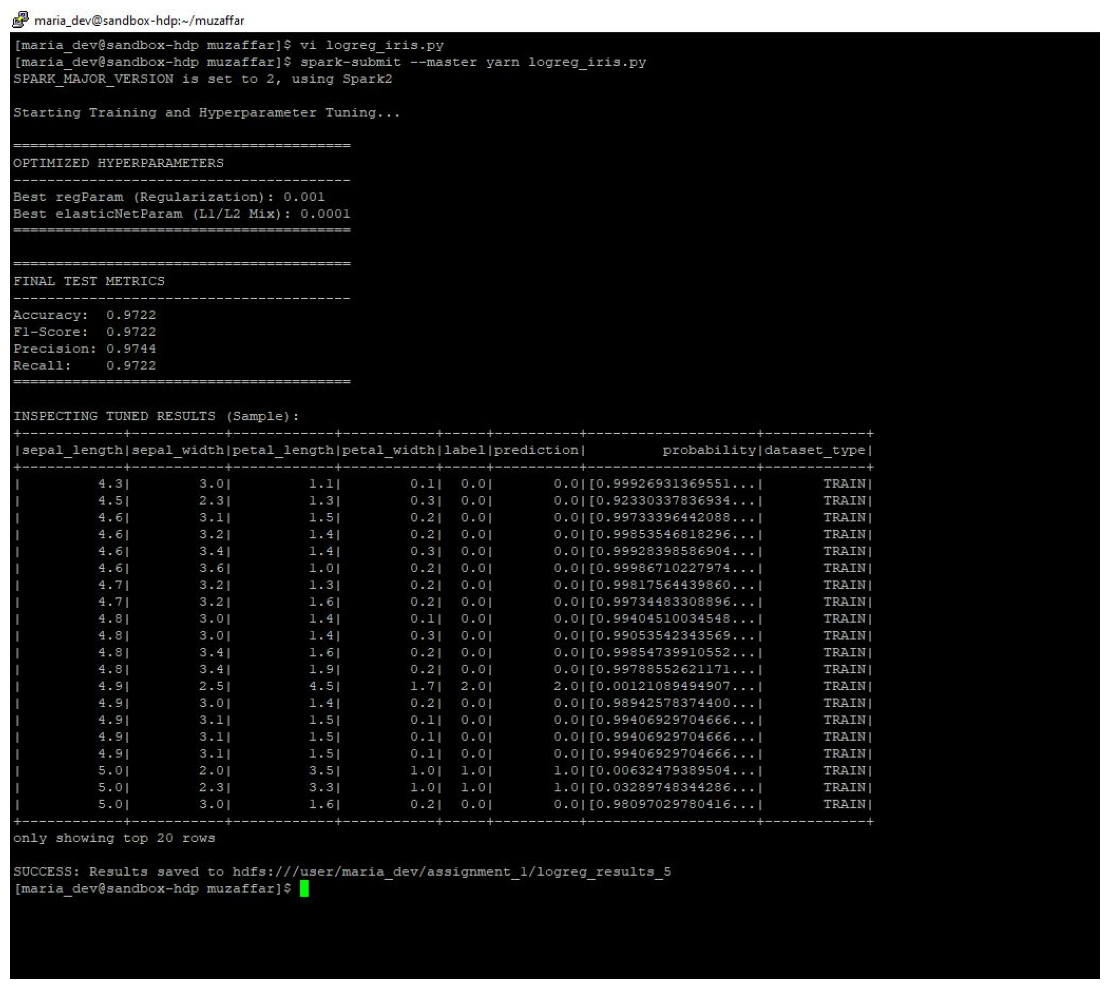

In [ ]:
show_github_img("images/logreg_results_5.JPG")

Next, three items are plotted for further understanding of the model's performance: <br>
1. Accuracy, F1 score, Precision and Recall for train and test data set <br>
2. Confusion matrix for both train and test dataset
3. ROC curve for both train and test dataset

Scanning folder: Spark_Results/logreg_results_5...
Automatically reading: part-00000-056da6f6-6ec2-4de9-b780-5b81a158167d-c000.snappy.parquet
Automatically reading: part-00001-056da6f6-6ec2-4de9-b780-5b81a158167d-c000.snappy.parquet

[SPARK OUTPUT INSPECTION - DECISION TREE]


,sepal_length,sepal_width,petal_length,petal_width,label,prediction,probability,dataset_type
0,4.3,3.0,1.1,0.1,0.0,0.0,"[0.9992693136955123, 0.0007306863041288978, 3....",TRAIN
1,4.5,2.3,1.3,0.3,0.0,0.0,"[0.9233033783693497, 0.07669662107398274, 5.56...",TRAIN
2,4.6,3.1,1.5,0.2,0.0,0.0,"[0.9973339644208855, 0.0026660355732945266, 5....",TRAIN
3,4.6,3.2,1.4,0.2,0.0,0.0,"[0.998535468182968, 0.0014645318149141614, 2.1...",TRAIN
4,4.6,3.4,1.4,0.3,0.0,0.0,"[0.9992839858690409, 0.000716014129127055, 1.8...",TRAIN



--- TRAIN METRICS ---
Accuracy:  0.9825
F1-Score:  0.9822
Precision: 0.9822
Recall:    0.9822

--- TEST METRICS ---
Accuracy:  0.9722
F1-Score:  0.9733
Precision: 0.9744
Recall:    0.9744


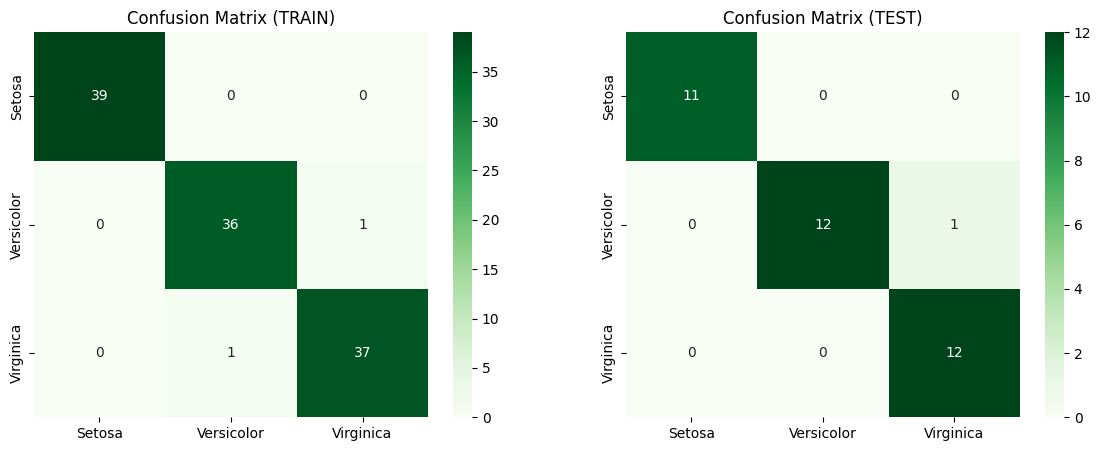

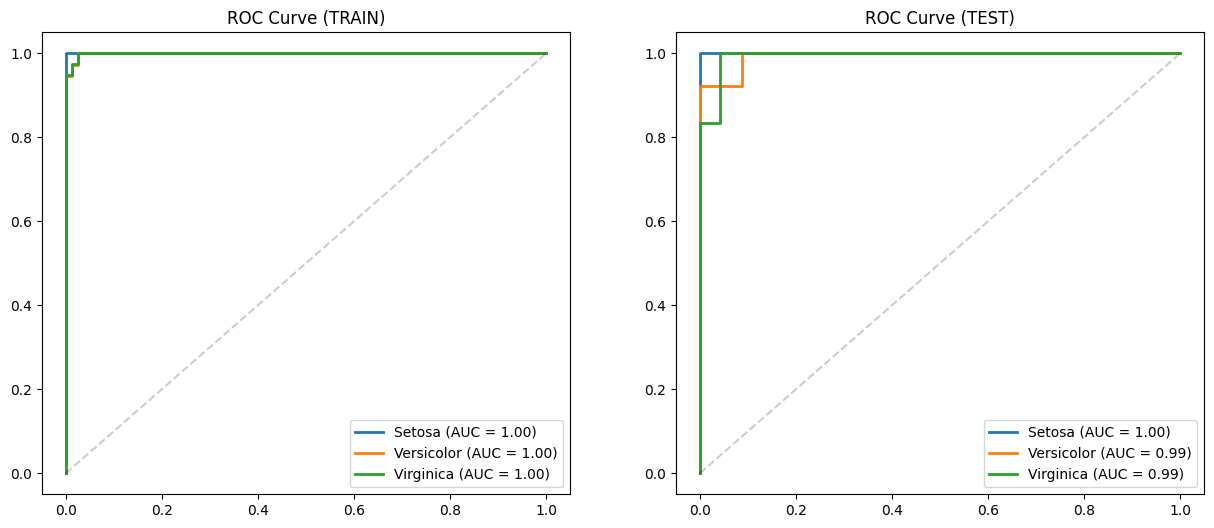

In [ ]:
# 1. Config
species_labels = ['Setosa', 'Versicolor', 'Virginica']
USER = "muzaffarizamuddin"
REPO = "P166246_Iris_Spark_STQD6324"

try:
    # 2. Just specify the folder path!
    folder = "Spark_Results/logreg_results_5"
    print(f"Scanning folder: {folder}...")

    df_results_logreg = load_parquet_auto(USER, REPO, folder)

    if not df_results_logreg.empty:
        # Clean probabilities
        df_results_logreg['probability'] = df_results_logreg['probability'].apply(
            lambda x: x['values'] if isinstance(x, dict) and 'values' in x else x
        )

        # Display and Plot
        print("\n[SPARK OUTPUT INSPECTION - DECISION TREE]")
        display(df_results_logreg.head(5))

        display_metrics_summary(df_results_logreg)
        plot_dual_confusion_matrix(df_results_logreg, species_labels)
        plot_dual_roc(df_results_logreg, species_labels)

except Exception as e:
    print(f"An error occurred: {e}")

#### 📊 4.1.3 Logistic Regression Performance Analysis

##### **a) Confusion Matrix Interpretation**
The Confusion Matrix provides a detailed breakdown of the model's predictions compared to the ground truth for both the Training and Test datasets. For Setosa flower the model achieved **100% accuracy** across both test and training datasets. Every sample (39 in Train, 11 in Test) was correctly identified without any false positives or false negatives.Versicolor and Virginica flowers have a Minor Overlap which leads to a small degree of misclassification between these two classes, which is expected due to the natural overlap in their physical measurements. In the training dataset the model correctly identified 36 Versicolor and 37 Virginica samples, with only 2 total errors across these classes. While in the test dataset the model correctly identified 12 Versicolor and Virginica samples, with only 1 total error. The strong diagonal lines in both matrices confirm high precision and consistent performance.

##### **b) ROC Curve & AUC Analysis**
The Receiver Operating Characteristic (ROC) curves illustrate the diagnostic ability of the classifier as its discrimination threshold is varied. Evaluating the area under the curve (AUC), starting with the training set, the model achieved a perfect **AUC of 1.00** for all three species, indicating ideal separation on the training data. The test dataset performance remained exceptional with an **AUC of 1.00 for Setosa** and **0.99 for both Versicolor and Virginica**. These near-perfect AUC scores demonstrate that the Logistic Regression model has an extremely high probability of correctly distinguishing between the species.

##### **c) Summary**

| Metric | Observation |
| :--- | :--- |
| **Separability** | **Setosa** is linearly separable from the other species, leading to perfect classification. |
| **Generalization** | The near-identical performance between the **TRAIN** and **TEST** sets proves the model is well-generalized and not overfitting. |
| **Model Stability** | The high AUC and Accuracy scores validate the effectiveness of the **initial Parameter optimization**, **Grid Search** and **3-Fold Cross-Validation** used during training. |

**Summary Verdict:** The Logistic Regression model is highly robust for the Iris classification task. The results are mathematically sound and demonstrate that the optimized parameters effectively handle the similarities between the Versicolor and Virginica species.

### 4.2 Decision Tree

Next we run a decision tree model in HDFS through Putty. The `dtree_iris.py` script is saved in Putty <br>
Then the script is called using the following command: <br>
spark-submit --master yarn dtree_iris.py <br>
The output is shown in the images below>>


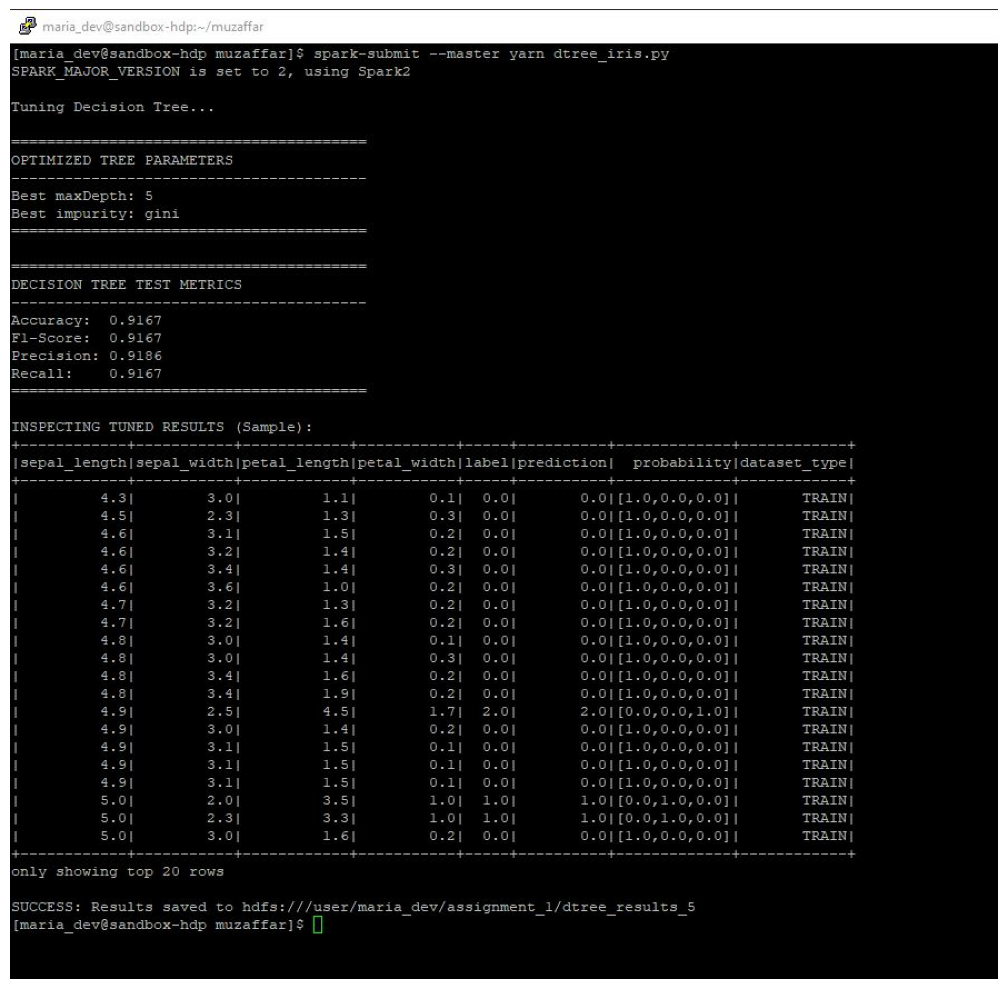

In [ ]:
show_github_img("images/dtree_results_5.JPG")

#### ⚙️ 4.2.1 Decision Tree: Hyperparameter Tuning & Results

Similar to logreg we use a 70:30 split for the train and test dataset. To identify the most effective structure for the Decision Tree, the dtree_iris.py script utilizes Spark’s ParamGridBuilder to perform a multi-dimensional search across the following hyperparameters shown in the python excerpt:

```python
# Implementation of the Grid Search in dtree_iris.py
paramGrid = ParamGridBuilder() \
        .addGrid(dt.maxDepth, [5,7,10]) \
        .addGrid(dt.impurity, ["gini", "entropy"]) \
        .addGrid(dt.minInstancesPerNode, [1]) \
        .build()
```

The result show that a maxDepth of 5 and impurity gini was the best parameter for this model and Parameter grid. Next we plot similar confusion matrix and ROC curve so that we can compare model to model in a detailed manner.

Scanning folder: Spark_Results/dtree_results_5...
Automatically reading: part-00000-1639b4a0-fb8d-4bfe-8ab8-533b26e1614b-c000.snappy.parquet
Automatically reading: part-00001-1639b4a0-fb8d-4bfe-8ab8-533b26e1614b-c000.snappy.parquet

[SPARK OUTPUT INSPECTION - DECISION TREE]


,sepal_length,sepal_width,petal_length,petal_width,label,prediction,probability,dataset_type
0,4.3,3.0,1.1,0.1,0.0,0.0,"[1.0, 0.0, 0.0]",TRAIN
1,4.5,2.3,1.3,0.3,0.0,0.0,"[1.0, 0.0, 0.0]",TRAIN
2,4.6,3.1,1.5,0.2,0.0,0.0,"[1.0, 0.0, 0.0]",TRAIN
3,4.6,3.2,1.4,0.2,0.0,0.0,"[1.0, 0.0, 0.0]",TRAIN
4,4.6,3.4,1.4,0.3,0.0,0.0,"[1.0, 0.0, 0.0]",TRAIN



--- TRAIN METRICS ---
Accuracy:  1.0000
F1-Score:  1.0000
Precision: 1.0000
Recall:    1.0000

--- TEST METRICS ---
Accuracy:  0.9167
F1-Score:  0.9200
Precision: 0.9209
Recall:    0.9209


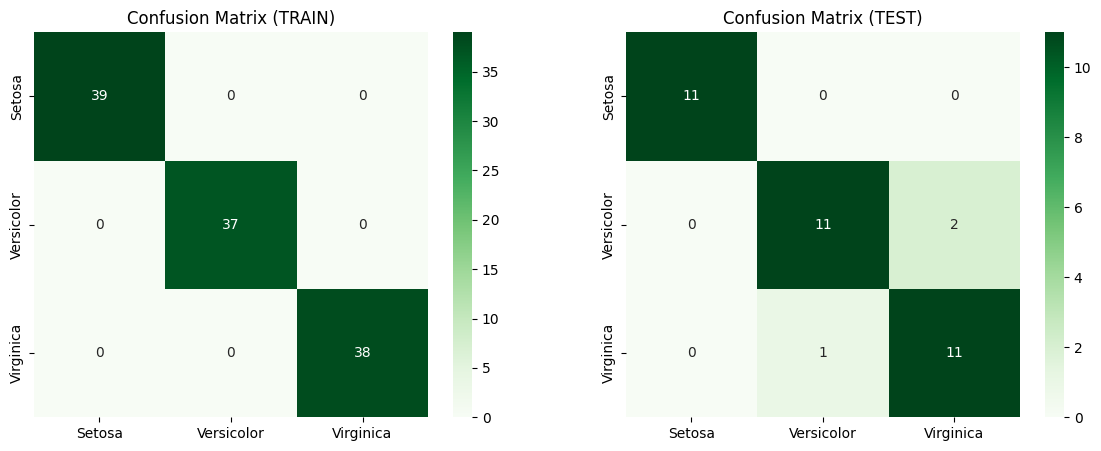

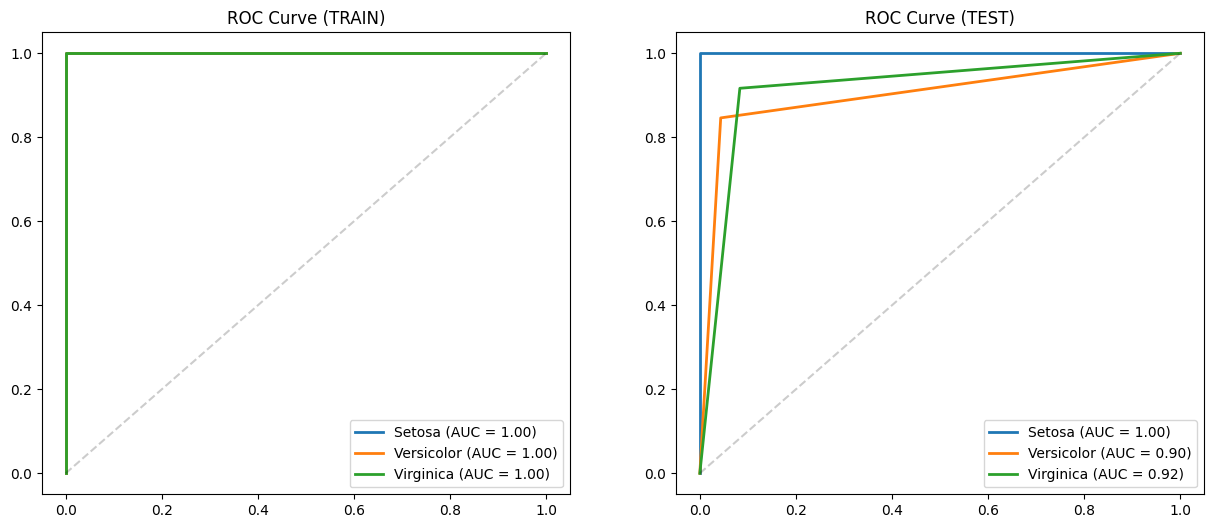

In [ ]:
# 1. Config
species_labels = ['Setosa', 'Versicolor', 'Virginica']
USER = "muzaffarizamuddin"
REPO = "P166246_Iris_Spark_STQD6324"

try:
    # 2. Just specify the folder path!
    folder = "Spark_Results/dtree_results_5"
    print(f"Scanning folder: {folder}...")

    df_results_dtree = load_parquet_auto(USER, REPO, folder)

    if not df_results_dtree.empty:
        # Clean probabilities
        df_results_dtree['probability'] = df_results_dtree['probability'].apply(
            lambda x: x['values'] if isinstance(x, dict) and 'values' in x else x
        )

        # Display and Plot
        print("\n[SPARK OUTPUT INSPECTION - DECISION TREE]")
        display(df_results_dtree.head(5))

        display_metrics_summary(df_results_dtree)
        plot_dual_confusion_matrix(df_results_dtree, species_labels)
        plot_dual_roc(df_results_dtree, species_labels)

except Exception as e:
    print(f"An error occurred: {e}")

#### 🌳 4.2.2. Decision Tree Model Discussion
##### a) Performance Metrics Analysis
The model achieved an overall **Accuracy of 91.67%**. While this is a high-performing result, it sits slightly below the Logistic Regression models, indicating that a single tree approach lacks the ensemble robustness found in other methods.

| Metric    | Value  | Interpretation |
| :---      | :---   | :--- |
| Accuracy  | 0.9167 | Correctly classified 33 out of 36 test samples. |
| Precision | 0.9186 | High confidence in species labeling; low false-positive rate. |
| Recall    | 0.9167 | Successfully captured the majority of each species. |
| F1-Score  | 0.9167 | Balanced performance between Precision and Recall. |

##### b) Visual Analysis of Confusion Matrix
Looking at the **Confusion Matrix (TEST)**, we observe the specific behavior of the Decision Tree. The errors occur exclusively between *Versicolor* and *Virginica*. This is expected as these species share overlapping petal dimensions, and a single Decision Tree uses "axis-parallel" splits defined by if else statements such as `if petal_width > 1.7` which can be too rigid for overlapping cases.
*   **Setosa (11/11):** Perfect classification. This species is linearly separable and easily handled by the initial tree splits.
*   **Versicolor (11/13):** Two samples were misclassified as *Virginica*.
*   **Virginica (11/12):** One sample was misclassified as *Versicolor*.

##### c) AUC and ROC Analysis
The lower AUC for *Versicolor* confirms it is the most difficult class for the Decision Tree to isolate. The sharp elbows in the ROC plot are characteristic of Decision Trees, as they provide discrete probability steps rather than smooth continuous scores. The next step to improve this model would be to investigate pruning, as noted by Breiman et al. (1984), who highlight that pruning and depth control of decision trees are critical for balancing the bias-variance tradeoff in classification tasks. However, pruning is not readily implemented in the Param Grid Builder function and was not investigated further as part of this study. Below is a summary of the AUC achieved using Decision tree which is markedly lower than logistic regression model in previous section:
*   **Setosa:** AUC = 1.00 (Perfect separation)
*   **Virginica:** AUC = 0.92
*   **Versicolor:** AUC = 0.90



### 4.3. Random Forest

Next we try to expand the decision tree model by investigating the use of multiple trees through the random forest model. The `rf_iris.py` script is saved in Putty <br>
Then the script is called using the following command: <br>
spark-submit --master yarn rf_iris.py <br>
The output is shown in the images below>>


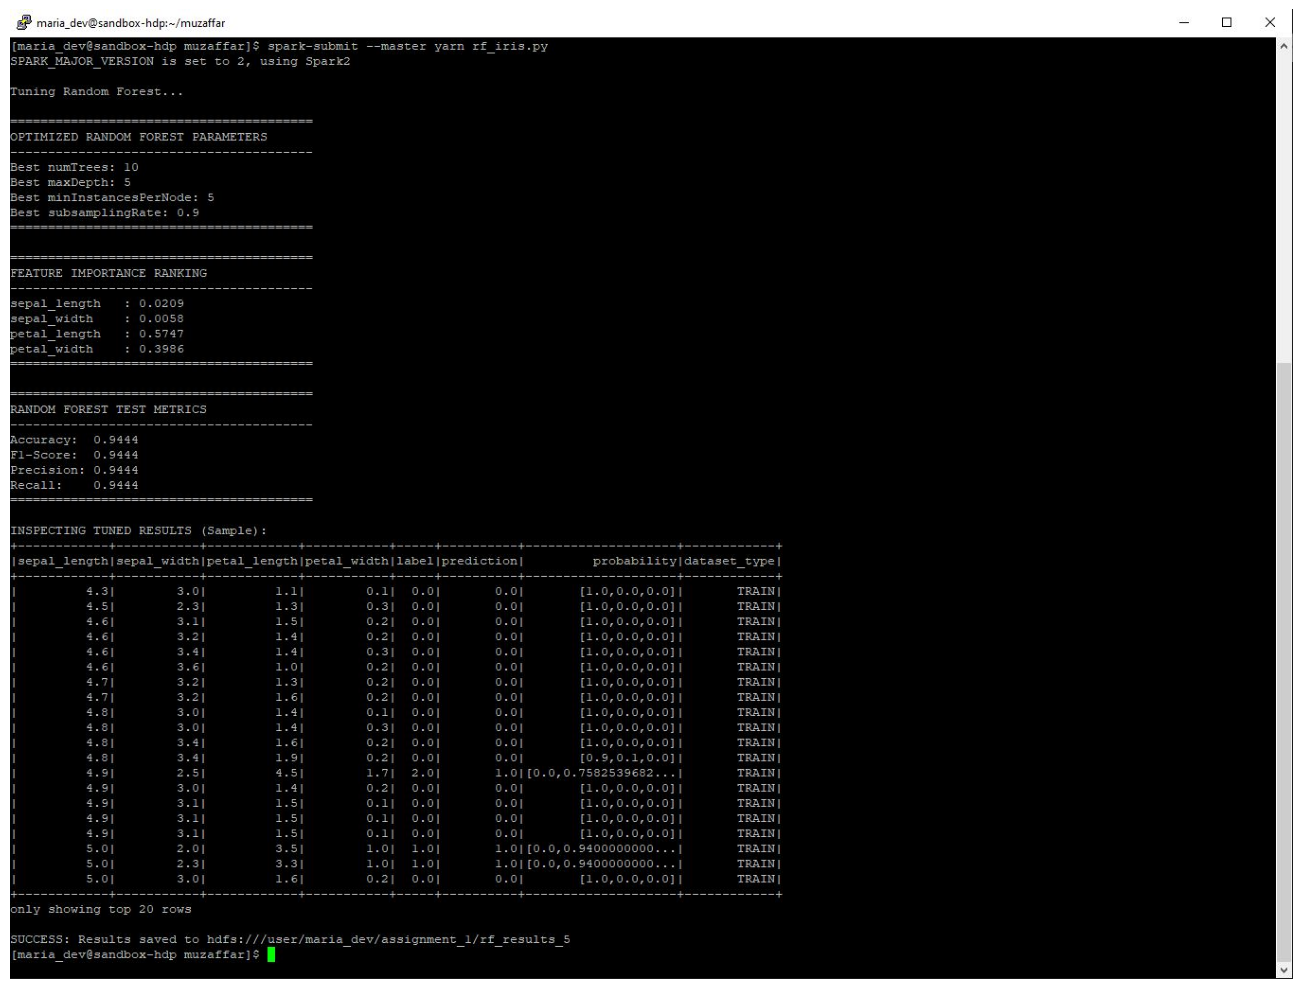

In [ ]:
show_github_img("images/rf_results_5.JPG")

#### ⚙️ 4.3.1 Random Forest: Hyperparameter Tuning & Results

Following the same **70:30 split** strategy and cross validation technique, the `rf_iris.py` script implements an ensemble-based search. Because Random Forest relies on Bagging (Bootstrap Aggregating), the ParamGridBuilder was configured to optimize the diversity and depth of the individual trees to prevent overfitting. Number of trees were evaluated at 5, 10 and 15. This controls the size of the ensemble. Increasing the number of trees generally improves stability and reduces variance by averaging the predictions of multiple learners. maxDepth was Tested at 5, 7 and 9 limiting how deep each individual tree can grow. A depth of 5-9 ensures each tree can capture feature relationships without becoming overly complex. SubsamplingRate was used to provide randomness that helps the model generalize better to unseen data and was evaluated at 0.8, 0.9 and 1.0. To keep the model relatively simple minimum instances per node was fixed at 5. This ensures that each leaf node has at least 5 samples, which acts as a form of regularization to prevent the model from learning noise in the data.

```python
# Implementation of the Grid Search in rf_iris.py
paramGrid = ParamGridBuilder() \
        .addGrid(rf.numTrees, [5, 10, 15]) \
        .addGrid(rf.maxDepth, [5, 7, 9]) \
        .addGrid(rf.minInstancesPerNode, [5]) \
        .addGrid(rf.subsamplingRate, [0.8, 0.9, 1.0]) \
        .build()
```

Similar to previous models, we then proceed to use the outputs from hadoop to plot a confusion matrix and ROC curve in the next cell.

Scanning folder: Spark_Results/rf_results_5...
Automatically reading: part-00000-beb662f8-adc9-470e-9ed6-40398be6f9a8-c000.snappy.parquet
Automatically reading: part-00001-beb662f8-adc9-470e-9ed6-40398be6f9a8-c000.snappy.parquet

[SPARK OUTPUT INSPECTION - DECISION TREE]


,sepal_length,petal_length,label,prediction,dataset_type
0,4.3,1.1,0.0,0.0,TRAIN
1,4.5,1.3,0.0,0.0,TRAIN
2,4.6,1.5,0.0,0.0,TRAIN
3,4.6,1.4,0.0,0.0,TRAIN
4,4.6,1.4,0.0,0.0,TRAIN



--- TRAIN METRICS ---
Accuracy:  0.9825
F1-Score:  0.9822
Precision: 0.9829
Recall:    0.9825

--- TEST METRICS ---
Accuracy:  0.9444
F1-Score:  0.9466
Precision: 0.9466
Recall:    0.9466


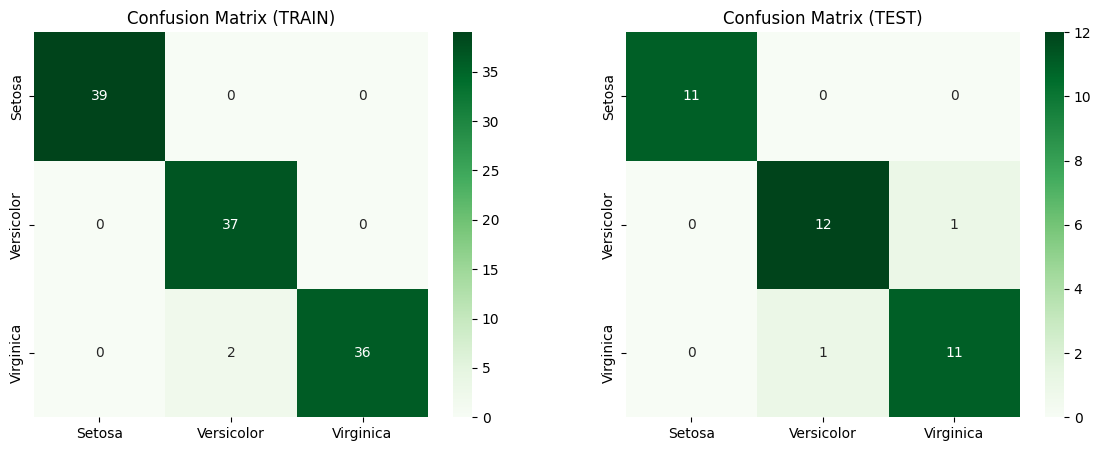

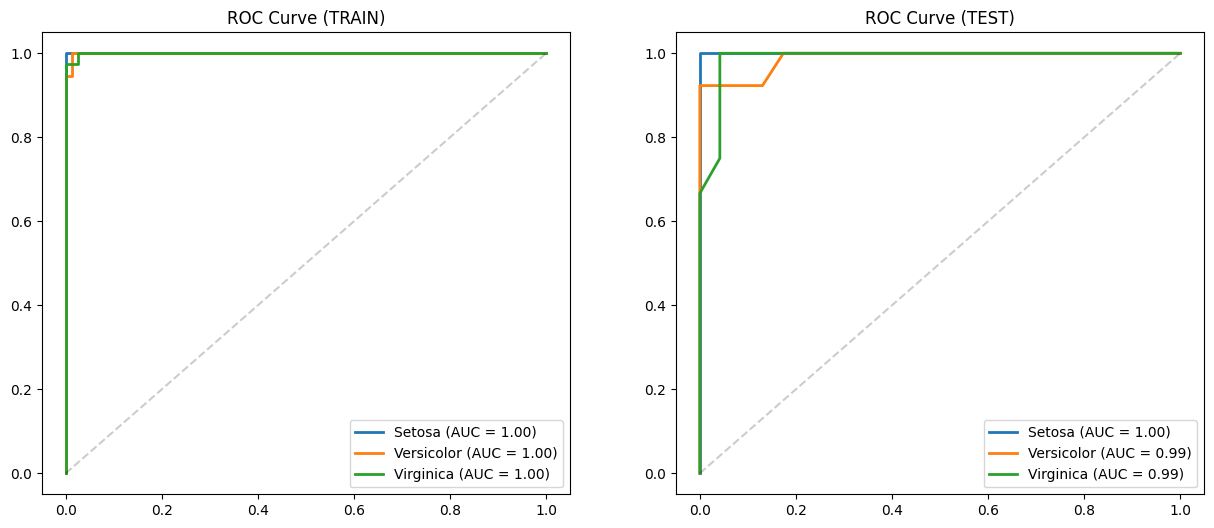

In [ ]:
# 1. Config
species_labels = ['Setosa', 'Versicolor', 'Virginica']
USER = "muzaffarizamuddin"
REPO = "P166246_Iris_Spark_STQD6324"

try:
    # 2. Just specify the folder path!
    folder = "Spark_Results/rf_results_5"
    print(f"Scanning folder: {folder}...")

    df_results_rf = load_parquet_auto(USER, REPO, folder)

    if not df_results_rf.empty:
        # Clean probabilities
        df_results_rf['probability'] = df_results_rf['probability'].apply(
            lambda x: x['values'] if isinstance(x, dict) and 'values' in x else x
        )

        # Display and Plot
        print("\n[SPARK OUTPUT INSPECTION - DECISION TREE]")
        display(df_results_rf[['sepal_length', 'petal_length', 'label', 'prediction', 'dataset_type']].head(5))

        display_metrics_summary(df_results_rf)
        plot_dual_confusion_matrix(df_results_rf, species_labels)
        plot_dual_roc(df_results_rf, species_labels)

except Exception as e:
    print(f"An error occurred: {e}")

#### ⚙️ 4.3.2 🌲🌲🌲 Random Forest Model Discussion

##### a) Model Configuration & Parameters
The Random Forest script arrived at the optimal hyperparameter that had 10 trees with a max depth of 5 and at a sampling rate of 0.9. By using 10 different trees and subsampling 90% of the data for each tree, the model creates an ensemble that is significantly more resistant to noise than a single decision tree.

##### b) Performance Metrics Analysis
The model achieved a higher **Accuracy of 94.44%** compared to the single decision tree model. This high score indicates that the voting mechanism of the Random Forest successfully corrected some of the rigid errors seen in simpler models.

| Metric    | Value  | Interpretation |
| :---      | :---   | :--- |
| Accuracy  | 0.9444 | Misclassified only 2 out of 36 test samples. |
| Precision | 0.9444 | Extremely high reliability in positive identifications. |
| Recall    | 0.9444 | Successfully captured nearly all instances of each species. |
| F1-Score  | 0.9444 | Demonstrates excellent harmonic balance across all classes. |

##### c) Visual Analysis of Confusion Matrix
The confusion matrix plotted using the test dataset reveals the random forest strength. The Random Forest reduced the misclassification rate between the overlapping *Versicolor* and *Virginica* species. By averaging the results of 10 trees, the model created a softer decision boundary that better handles the statistical variance of the Iris flowers. The averaging of 10 trees follows the principle that multiple weak learners combine to form a robust classifier, a method popularized by Breiman (2001) for handling high-dimensional data variance.
*   **Setosa (11/11):** Remained perfectly classified (100% accuracy).
*   **Versicolor (12/13):** Only 1 sample was misclassified as *Virginica*. This is an improvement over the single Decision Tree.
*   **Virginica (11/12):** Only 1 sample was misclassified as *Versicolor*.

##### d) AUC and ROC Analysis
The test-set ROC Curve shows near-perfect separation capabilities. Unlike the Decision Tree's ROC which had lower AUC scores (0.90-0.92), the Random Forest pushed the AUC for all classes to **0.99**. The smoother curves indicate that the model's probability estimates are much more refined, allowing for nearly perfect discrimination between classes.
*   **Setosa:** AUC = 1.00 (Perfect)
*   **Versicolor:** AUC = 0.99
*   **Virginica:** AUC = 0.99

### 4.4. Naive Bayes

We would like to also investigate the usage of another simple model for this dataset through the naive bayes model. To conduct the simulation the `nb_iris.py` script is saved in Putty <br>
Then the script is called using the following command: <br>
spark-submit --master yarn nb_iris.py <br>
The output is shown in the images below>>


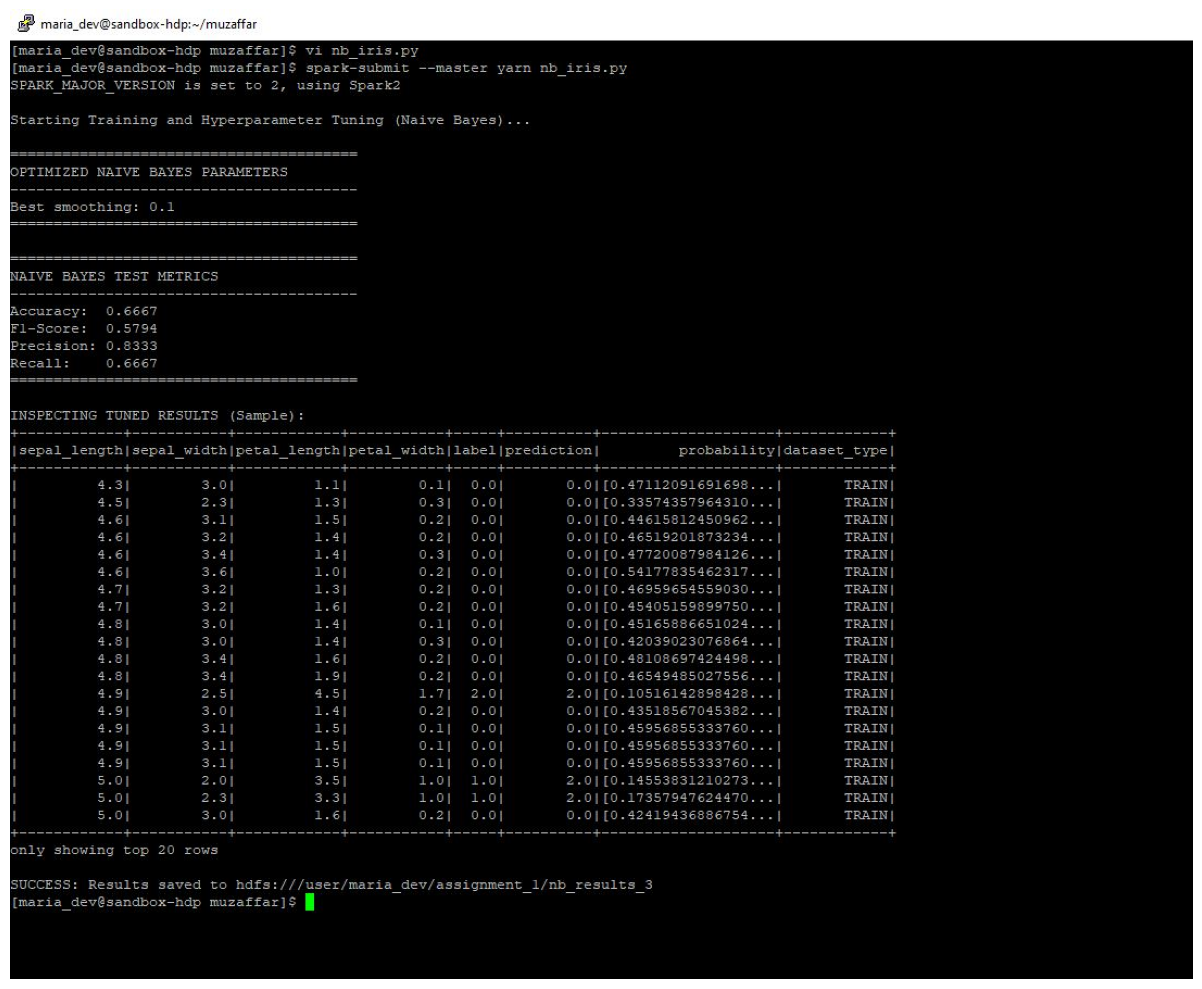

In [ ]:
show_github_img("images/nb_result_5.JPG")

#### ⚙️ 4.4.1 Naive Bayes: Hyperparameter Tuning & Results

The `nb_iris.py` script implements the Naive Bayes classifier, which is a probabilistic model based on Bayes' Theorem. This model assumes that all input features are independent of one another. The `ParamGridBuilder` was used to optimize the smoothing parameter which was evaluated at 0.1, 1.0 and 5.0. Also known as Laplace smoothing, this parameter is used to handle cases where a feature-label combination might not appear in the training set. A smaller value like 0.1 allows for more precise probability estimates, while larger values like 5.0 smooth the probabilities more aggressively to prevent overfitting. Below is the implementation in python:

```python
# Implementation of the Grid Search in nb_iris.py
paramGrid = ParamGridBuilder() \
        .addGrid(nb.smoothing, [0.1, 1.0, 5.0]) \
        .build()
```
Similar to previous models, we proceed to plot the confusion matrix and ROC curve for naive bayes in the next cell.

Scanning folder: Spark_Results/nb_results_3...
Automatically reading: part-00000-d5310c0c-ad16-4592-9d3b-8a874ca297e3-c000.snappy.parquet
Automatically reading: part-00001-d5310c0c-ad16-4592-9d3b-8a874ca297e3-c000.snappy.parquet

[SPARK OUTPUT INSPECTION - DECISION TREE]


,sepal_length,petal_length,label,prediction,dataset_type
0,4.3,1.1,0.0,0.0,TRAIN
1,4.5,1.3,0.0,0.0,TRAIN
2,4.6,1.5,0.0,0.0,TRAIN
3,4.6,1.4,0.0,0.0,TRAIN
4,4.6,1.4,0.0,0.0,TRAIN



--- TRAIN METRICS ---
Accuracy:  0.6579
F1-Score:  0.5495
Precision: 0.4977
Recall:    0.6491

--- TEST METRICS ---
Accuracy:  0.6667
F1-Score:  0.6032
Precision: 0.8333
Recall:    0.6923


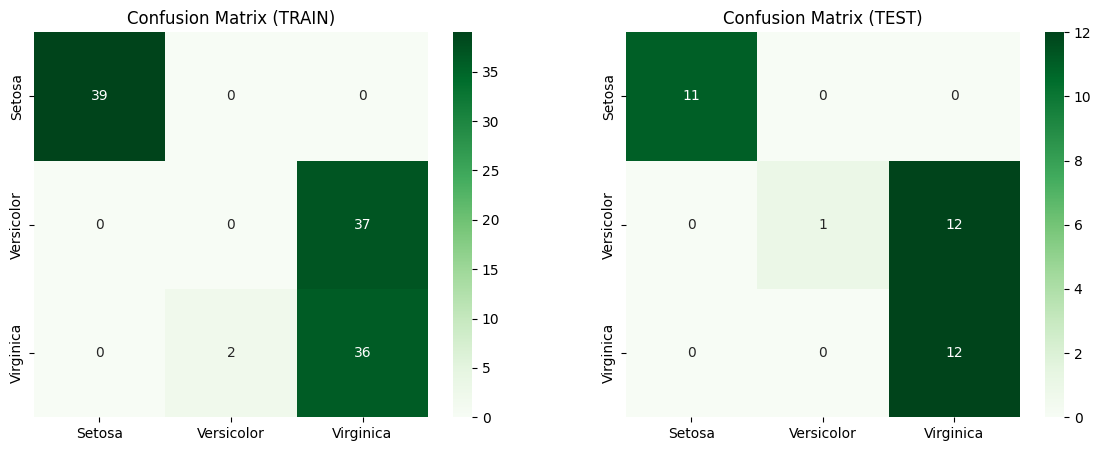

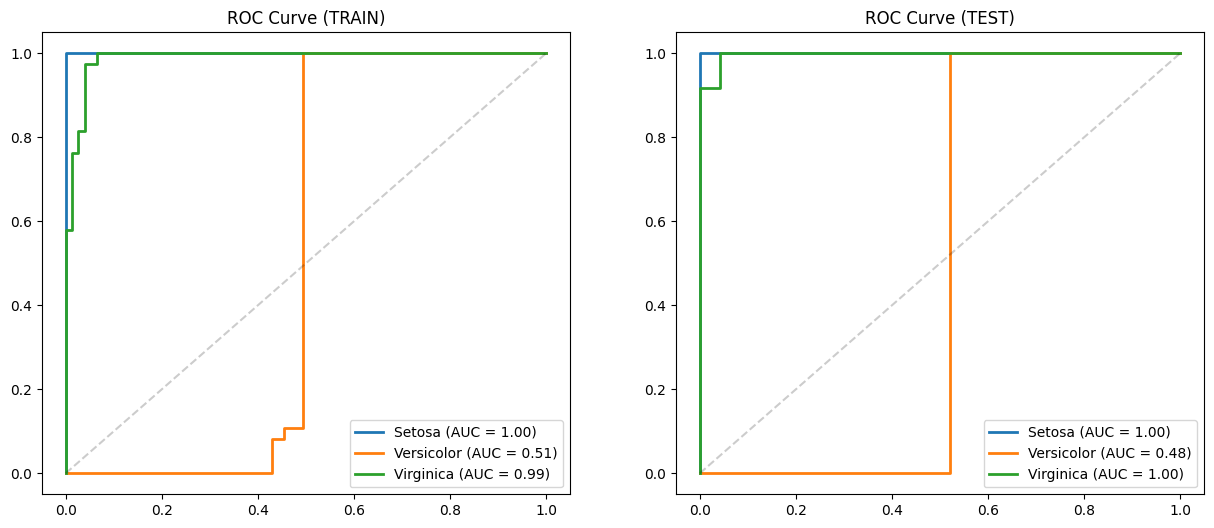

In [ ]:
# 1. Config
species_labels = ['Setosa', 'Versicolor', 'Virginica']
USER = "muzaffarizamuddin"
REPO = "P166246_Iris_Spark_STQD6324"

try:
    # 2. Just specify the folder path!
    folder = "Spark_Results/nb_results_3"
    print(f"Scanning folder: {folder}...")

    df_results_nb = load_parquet_auto(USER, REPO, folder)

    if not df_results_rf.empty:
        # Clean probabilities
        df_results_nb['probability'] = df_results_nb['probability'].apply(
            lambda x: x['values'] if isinstance(x, dict) and 'values' in x else x
        )

        # Display and Plot
        print("\n[SPARK OUTPUT INSPECTION - DECISION TREE]")
        display(df_results_nb[['sepal_length', 'petal_length', 'label', 'prediction', 'dataset_type']].head(5))

        display_metrics_summary(df_results_nb)
        plot_dual_confusion_matrix(df_results_nb, species_labels)
        plot_dual_roc(df_results_nb, species_labels)

except Exception as e:
    print(f"An error occurred: {e}")

#### 📉 4.4.2.  Naive Bayes Model Discussion

##### a) Model Configuration & Parameters
The hyperparameter tuning for Naive Bayes arrived at a smoothing parameter of 0.1. One major contrant of this model is that it assumes feature independence, which is a significant theoretical hurdle for the Iris dataset where physical dimensions are naturally correlated. Cross correlation can occur both between petal and sepal dimensions as well as cross species dimensional correlation as seen in the overlap of Versicolor and Virginica.

##### b) Performance Metrics Analysis
Naive Bayes was the lowest-performing model in this experiment, struggling significantly with class separation outside of the *Setosa* species.

| Metric    | Value  | Interpretation |
| :---      | :---   | :--- |
| **Accuracy** | **0.6667** | Only 2/3 of the test set was correctly identified. |
| **F1-Score** | 0.5794 | Indicates a heavy imbalance in how the model handles different classes. |
| **Precision** | 0.8333 | High precision suggests that when it predicts a class, it is often correct, but it fails to find many others. |
| **Recall** | 0.6667 | The model failed to "recall" or identify 33% of the actual instances. |

##### c) Visual Analysis of Errors (Confusion Matrix)
The Confusion Matrix plotted based on test dataset provides a clear picture of the model's failure points. The model effectively collapsed the *Versicolor* and *Virginica* classes into a single category. This is a classic symptom of the model being unable to handle the overlapping feature distributions when treated independently.
*   **Setosa (11/11):** Perfect classification. Like other models, Naive Bayes has no trouble isolating this distinct species.
*   **Versicolor (1/13):** Significant misclassification. **12 out of 13** *Versicolor* samples were misclassified as *Virginica*.
*   **Virginica (12/12):** Paradoxically perfect classification for this class, but largely because the model defaulted most non-Setosa predictions here.

##### d) AUC and ROC Analysis
ROC curve plotted using the test dataset highlights the drastic difference in class-wise performance. An AUC of 0.50 represents random guessing. An AUC of **0.48** indicates that for the *Versicolor* species, the model is performing worse than random chance. The horizontal line in the ROC plot suggests the model is unable to distinguish this class across various probability thresholds. Naive Bayes proved unsuitable for the Iris dataset in this distributed environment. The model's core assumption—that sepal and petal measurements do not influence one another—is biologically incorrect. In a Naive Bayes context, a long petal does not imply a wide petal, but in reality, they can be correlated. This structural mismatch resulted in a model that essentially gave up on distinguishing *Versicolor* from *Virginica*, leading to the poor **66.67% accuracy**. Zhang (2004) highlights that while Naive Bayes is computationally efficient, its performance significantly degrades when the conditional independence assumption is violated by highly correlated features. Nonetheless this model serves as a baseline for understanding what could be a bad model with this dataset.

*   **Setosa:** AUC = 1.00 (Perfect separation).
*   **Virginica:** AUC = 1.00 (Likely inflated due to the classification bias toward this class).
*   **Versicolor:** **AUC = 0.48**.

### 4.5. Neural Network

For a neural network example, the most basic model within the class, a multilayer perceptron, is used, hence the Python script is named `mlp_iris.py` <br>
To conduct the analysis the `mlp_iris.py` script is saved in Putty <br>
Then the script is called using the following command: <br>
spark-submit --master yarn mlp_iris.py <br>
The output is shown in the images below>>


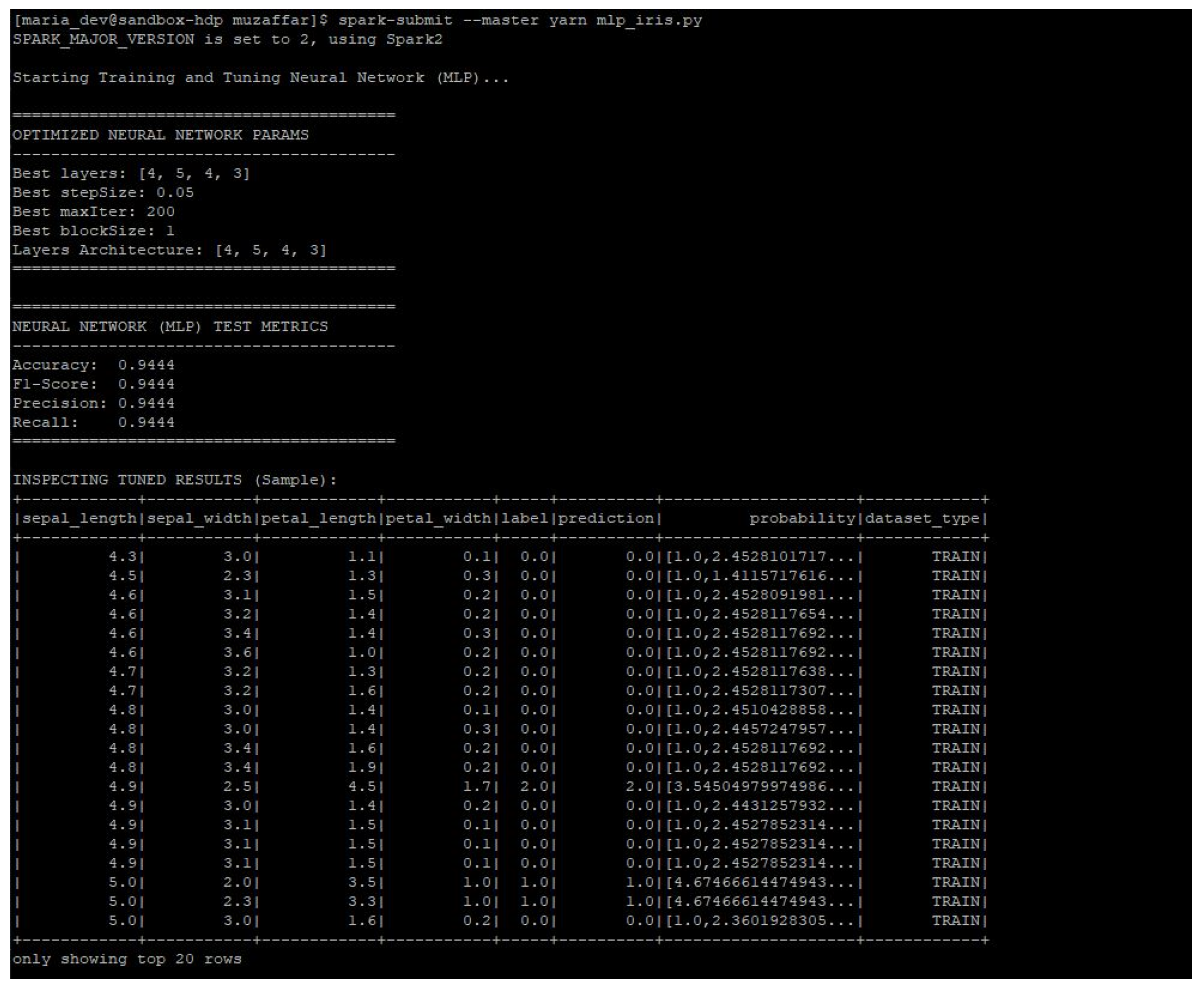

In [ ]:
show_github_img("images/mlp_result_5.JPG")

#### ⚙️ 4.5.1 Multi-Layer Perceptron (MLP): Hyperparameter Tuning & Results

The `mlp_iris.py` script implements a deep learning approach using a Multi-Layer Perceptron. Unlike the previous statistical or tree-based models, the MLP relies on weight optimization via backpropagation. The `ParamGridBuilder` was configured to tune the network's architecture and learning dynamics. The hyperparameter layers  was evaluated at two distinct architectures `[4, 5, 4, 3]` (two hidden layers) and `[4, 8, 3]` (one hidden layer). The first number represents the 4 input features, and the last represents the 3 output classes. Then the parameter stepSize was tested at `[0.05, 0.1]`. stepSize is the learning rate for the optimization algorithm. A smaller step size allows for more stable convergence during training. Maximum number of iteration is set to 200. This ensures the network has enough training iteration to minimize the error function across the distributed dataset. And finally, blockSize was set to 1. A block size of 1 allows for stochastic gradient descent updates, which may help neural networks find better local minima. This parameter was not varied further as the study focuses more on a preliminary comparison of models and adding more parameters may take more time computationally.

```python
# Implementation of the Grid Search in mlp_iris.py
paramGrid = ParamGridBuilder() \
        .addGrid(mlp.layers, [[4, 5, 4, 3], [4, 8, 3]]) \
        .addGrid(mlp.stepSize, [0.05, 0.1]) \
        .addGrid(mlp.maxIter, [200]) \
        .addGrid(mlp.blockSize, [1]) \
        .build()
```

Similarly, we then plot the diagnostic confusion matrix and ROC curve for Multi-layer perceptron in the next cell.

Scanning folder: Spark_Results/mlp_results_5...
Automatically reading: part-00000-79d58be9-c1c7-45ff-8a51-3648e33d10c5-c000.snappy.parquet
Automatically reading: part-00001-79d58be9-c1c7-45ff-8a51-3648e33d10c5-c000.snappy.parquet

[SPARK OUTPUT INSPECTION - DECISION TREE]


,sepal_length,petal_length,label,prediction,dataset_type
0,4.3,1.1,0.0,0.0,TRAIN
1,4.5,1.3,0.0,0.0,TRAIN
2,4.6,1.5,0.0,0.0,TRAIN
3,4.6,1.4,0.0,0.0,TRAIN
4,4.6,1.4,0.0,0.0,TRAIN



--- TRAIN METRICS ---
Accuracy:  1.0000
F1-Score:  1.0000
Precision: 1.0000
Recall:    1.0000

--- TEST METRICS ---
Accuracy:  0.9444
F1-Score:  0.9466
Precision: 0.9466
Recall:    0.9466


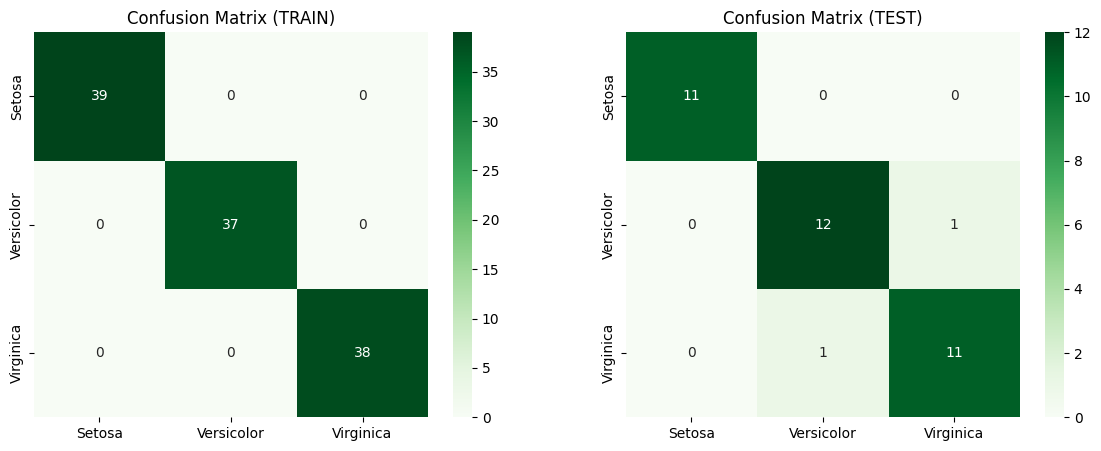

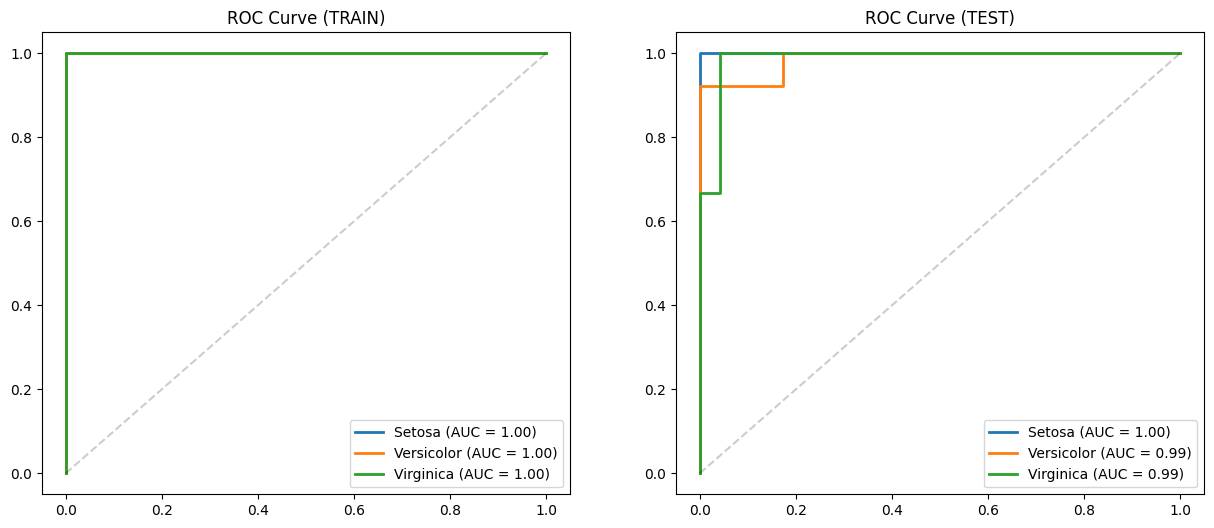

In [ ]:
# 1. Config
species_labels = ['Setosa', 'Versicolor', 'Virginica']
USER = "muzaffarizamuddin"
REPO = "P166246_Iris_Spark_STQD6324"

try:
    # 2. Just specify the folder path!
    folder = "Spark_Results/mlp_results_5"
    print(f"Scanning folder: {folder}...")

    df_results_mlp = load_parquet_auto(USER, REPO, folder)

    if not df_results_mlp.empty:
        # Clean probabilities
        df_results_mlp['probability'] = df_results_mlp['probability'].apply(
            lambda x: x['values'] if isinstance(x, dict) and 'values' in x else x
        )

        # Display and Plot
        print("\n[SPARK OUTPUT INSPECTION - DECISION TREE]")
        display(df_results_mlp[['sepal_length', 'petal_length', 'label', 'prediction', 'dataset_type']].head(5))

        display_metrics_summary(df_results_mlp)
        plot_dual_confusion_matrix(df_results_mlp, species_labels)
        plot_dual_roc(df_results_mlp, species_labels)

except Exception as e:
    print(f"An error occurred: {e}")

#### 🧠 4.5.2 Multi-Layer Perceptron (MLP) Model Discussion

##### a) Model Configuration & Parameters
The Multi-Layer Perceptron was optimized with an intent to handle potential non-linear relationships within the Iris dataset. The model ultimately arrived at the best architecture of 4 inputs, two hidden layers of 5 and 4 neurons respectively, and 3 output classes. A `stepSize` of 0.05 was chosen by the grid search which ensured stable leaning rate over the fixed **200 iterations**, allowing the network to converge effectively on the Hadoop cluster.

##### b) Performance Metrics Analysis
The MLP achieved an **Accuracy of 94.44%**, placing it in the top tier of models alongside the Random Forest.

| Metric    | Value  | Interpretation |
| :---      | :---   | :--- |
| **Accuracy** | **0.9444** | Misclassified only 2 samples out of 36 in the test set. |
| **F1-Score** | 0.9444 | High performance across all species, matching the ensemble results. |
| **Precision**| 0.9444 | Strong ability to avoid false positives in species identification. |
| **Recall** | 0.9444 | Successfully identified almost all actual members of each class. |

##### c) Visual Analysis of Errors (Confusion Matrix)
The Confusion Matrix on the test dataset highlights the network's predictive capabilities. The MLP successfully modeled the complex overlap between *Versicolor* and *Virginica*. By using hidden layers, the network created non-linear decision boundaries that are more flexible than those of a single Decision Tree, resulting in fewer errors.
* **Setosa (11/11):** 100% classification accuracy. The MLP learned the distinct boundaries of this species perfectly.
* **Versicolor (12/13):** Only **1 sample** was misclassified as *Virginica*.
* **Virginica (11/12):** Only **1 sample** was misclassified as *Versicolor*.

##### d) AUC and ROC Analysis
The smooth curves and near-maximized AUC values indicate that the MLP’s probabilistic predictions are highly refined. This confirms that the network is not just guessing but has developed high confidence in its class assignments across various thresholds. According to **Haykin (2009)**, the use of hidden layers in backpropagation networks—such as the parameter we used `[4, 5, 4, 3]` allows for the approximation of complex, non-linear feature mappings.

The MLP proved to be a highly robust model for the Iris dataset. Its ability to achieve **94.44% accuracy** demonstrates that deep learning architectures are effective for structured biological data when properly tuned. While more computationally expensive than Logistic Regression, the MLP's performance parity with the Random Forest makes it a strong candidate for complex classification tasks where non-linear patterns are expected. MLP is much more capable to cater for edge cases but it may need more tuning in order to gain a higher accuracy or F1 score.The ROC Curve on the test dataset confirms near-perfect discriminatory power:
* **Setosa:** AUC = 1.00.
* **Versicolor:** AUC = 0.99.
* **Virginica:** AUC = 0.99.


## 5. Model Comparison

### **5.1 Hyperparameter Tuning Summary & Selected Parameters**

This table summarizes the parameters evaluated during the grid search phase for each model and highlights the optimal parameters chosen based on 3-fold cross-validation results.

| Model                  | Parameter              | Values Evaluated                           | Chosen Parameter             |
| :--------------------- | :--------------------- | :----------------------------------------- | :-------------------------- |
| **Logistic Regression**| `regParam`             | `[0.001, 0.002, 0.003]`                    | `0.001`                     |
|                        | `elasticNetParam`      | `[0.0001, 0.00001, 0.000001]`              | `0.0001`                    |
| **Decision Tree**      | `maxDepth`             | `[5, 7, 10]`                               | `5`                         |
|                        | `impurity`             | `["gini", "entropy"]`                      | `"gini"`                    |
|                        | `minInstancesPerNode`  | `[1]`                                      | `1`                         |
| **Random Forest**      | `numTrees`             | `[5, 10, 15]`                              | `10`                        |
|                        | `maxDepth`             | `[5, 7, 9]`                                | `5`                         |
|                        | `subsamplingRate`      | `[0.8, 0.9, 1.0]`                          | `0.9`                       |
|                        | `minInstancesPerNode`  | `[5]`                                      | `5`                         |
| **Naive Bayes**        | `smoothing`            | `[0.1, 1.0, 5.0]`                          | `0.1`                       |
| **Neural Network (MLP)**| `layers`               | `[[4, 5, 4, 3], [4, 8, 3]]`                | `[4, 5, 4, 3]`              |
|                        | `stepSize`             | `[0.05, 0.1]`                              | `0.05`                      |
|                        | `maxIter`              | `[200]`                                    | `200`                       |
|                        | `blockSize`            | `[1]`                                      | `1`                         |

---

In the next cell, we plot and compare each model in a consolidated format.

In [ ]:
# This function compiles and compares metrics from multiple models.
def compile_model_comparison(model_dict):
    """
    Compiles metrics from multiple result dataframes into one summary table.
    model_dict: {'Model Name': dataframe}
    """
    comparison_list = []

    for name, df in model_dict.items():
        # Ensure we only evaluate the TEST set
        df['dataset_type'] = df['dataset_type'].str.upper()
        test_subset = df[df['dataset_type'] == 'TEST']

        if not test_subset.empty:
            # Calculate metrics
            report = classification_report(test_subset['label'],
                                           test_subset['prediction'],
                                           output_dict=True)

            comparison_list.append({
                'Model': name,
                'Accuracy': report['accuracy'],
                'F1-Score': report['macro avg']['f1-score'],
                'Precision': report['macro avg']['precision'],
                'Recall': report['macro avg']['recall']
            })

    # Create DataFrame and sort by Accuracy
    comp_df = pd.DataFrame(comparison_list)
    return comp_df.sort_values(by='Accuracy', ascending=False)

def plot_model_comparison(comp_df):
    """
    Plots a grouped bar chart for Accuracy and F1-Score.
    """
    # Reshape data for plotting
    melted_df = comp_df.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score'],
                             var_name='Metric', value_name='Score')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='viridis')

    plt.title('Cross-Model Performance Comparison (Test Set)', fontsize=15)
    plt.ylim(0.7, 1.05) # Zoom in to see differences
    plt.ylabel('Score (0.0 - 1.0)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.show()


FINAL MODEL PERFORMANCE LEADERBOARD (TEST SET):


,Model,Accuracy,F1-Score,Precision,Recall
0,Logistic Regression,0.972222,0.973333,0.974359,0.974359
2,Random Forest,0.944444,0.946581,0.946581,0.946581
4,Neural Network (MLP),0.944444,0.946581,0.946581,0.946581
1,Decision Tree,0.916667,0.920000,0.920940,0.920940
3,Naive Bayes,0.666667,0.603175,0.833333,0.692308


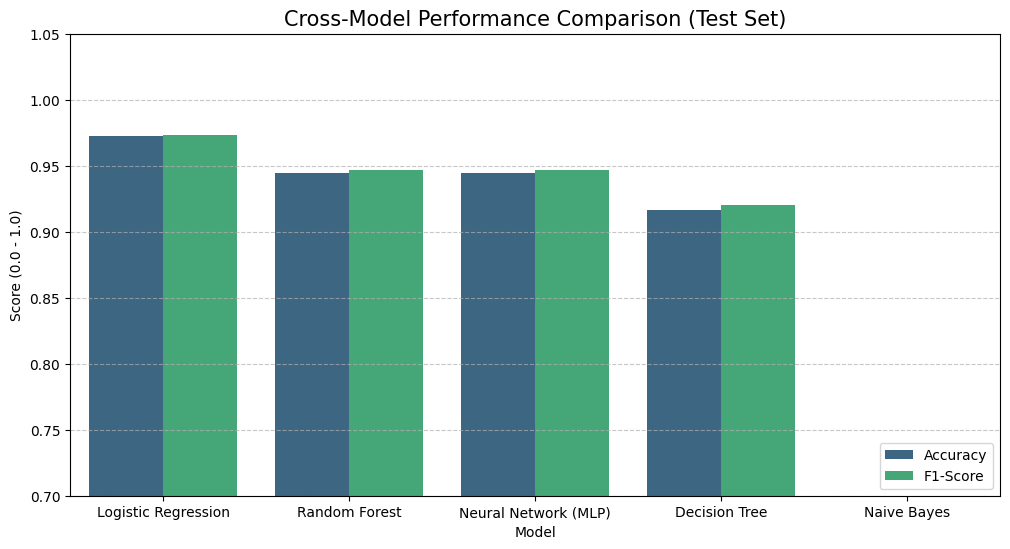

In [ ]:
# 1. Map dataframes to their display names
all_models = {
    'Logistic Regression': df_results_logreg,
    'Decision Tree': df_results_dtree,
    'Random Forest': df_results_rf,
    'Naive Bayes': df_results_nb,
    'Neural Network (MLP)': df_results_mlp
}

try:
    # 2. Generate the comparison table
    df_comparison = compile_model_comparison(all_models)

    # 3. Display the Leaderboard
    print("FINAL MODEL PERFORMANCE LEADERBOARD (TEST SET):")
    display(df_comparison.style.highlight_max(axis=0, color='lightgreen', subset=['Accuracy', 'F1-Score', 'Precision', 'Recall']))

    # 4. Visualize
    plot_model_comparison(df_comparison)

    # 5. Identify the Winner
    winner = df_comparison.iloc[0]['Model']
    win_acc = df_comparison.iloc[0]['Accuracy']

except Exception as e:
    print(f"Error compiling comparison: {e}")

### **5.2 Model Performance Ranking**
The models can be categorized into three distinct performance tiers based on their ability to generalize to the test set:

| Rank | Model | Accuracy | F1-Score | Status |
| :--- | :--- | :---: | :---: | :--- |
| **1** | **Logistic Regression** | **0.9722** | **0.9733** | **Leader** |
| **2** | **Random Forest** | 0.9444 | 0.9466 | Top Tier |
| **3** | **Neural Network (MLP)**| 0.9444 | 0.9466 | Top Tier |
| **4** | **Decision Tree** | 0.9167 | 0.9200 | Mid Tier |
| **5** | **Naive Bayes** | 0.6667 | 0.6032 | Not suitable |

---

### **5.3 Key Comparative Insights**

Despite being one of the simpler algorithms, **Logistic Regression** achieved the highest accuracy of **97.22%** showing linear seperation line is sufficient to produce a reasonable classification. This indicates that the Iris dataset features (petal/sepal dimensions) are largely linearly separable. Logistic regression outperformed more complex models like the Neural Network and Random Forest while requiring significantly less computational time and fewer hyperparameters to tune.

Random Forest (94.44%) outperformed the standalone Decision Tree (91.67%) model showing that a multiple tree approach could cater for more edge cases. By averaging 10 different trees, the Random Forest smoothed out the rigid decision boundaries of the single Decision Tree. Increasing the number of trees further may risk overfitting especially to small datasets which may be the reason why the grid search arrived at a conservative 10 number of trees.

The multi-layer perceptron matched the Random Forest at 94.44% accuracy.While highly accurate, the MLP required a deep `[4, 5, 4, 3]` architecture and 200 iterations to match the performance that Logistic Regression achieved in a more efficient manner. For small structured datasets like Iris, the overhead of a Neural Network may not always be justified by the marginal gains.

Naive Bayes was the only model to fall below the 90% threshold, finishing at a very low 66.67% accuracy. ROC curve shows that for Versicolor, the model performed worse that random guessing showing that this model isn't suitable for the iris dataset. Naive Bayes assumes all features are independent. However, in an Iris flower, petal length and width are highly correlated. This structural mismatch led to the model effectively failing to distinguish *Versicolor* from *Virginica*.

## 6. Prediction

Next, the optimized hyperparameters from the Hadoop cluster (YARN) are used to run a local machine learning model using scikit-learn.
This enables local use of the predict function without dependence on the Hadoop cluster, facilitating easy classification of new data points.


#### 6.1 Prediction using localized scikit-learn
Scikit-learn is used as it can be easily integrated into localized Jupyter notebooks without Java support and is faster in implementation for visualizing purposes


In [ ]:
import pandas as pd
import requests
import io
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load data
url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/main/iris.csv"
s = requests.get(url).content
df_iris = pd.read_csv(io.StringIO(s.decode('utf-8')))

# --- UPDATED DATA PREPROCESSING ---
# Strip any hidden spaces
df_iris['species'] = df_iris['species'].str.strip()

# UPDATED: Matches the 'Iris-' prefix used in hadoop cluster
label_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

df_iris['label'] = df_iris['species'].map(label_mapping)

# Drop any rows that couldn't be mapped or have missing data
df_iris = df_iris.dropna(subset=['label'])
# -----------------------------------

# 2. Define features
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_train_df = df_iris[cols]
y_train = df_iris['label'].astype(int)

# 3. Fit the Scaler (Locks feature names)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_df), columns=cols)

# 4. Initialize and Fit Models (Using Optimized Spark Parameters)
models = {
    # regParam 0.001 and elasticNetParam 0.0001 (L2 dominated)
    "Logistic Regression": LogisticRegression(C=1/0.001, l1_ratio=0.0001, solver='saga', max_iter=1000
    ).fit(X_train_scaled, y_train),

    # maxDepth 5 and Gini impurity
    "Decision Tree": DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42
    ).fit(X_train_df, y_train),

    # numTrees 10 and maxDepth 5
    "Random Forest": RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42
    ).fit(X_train_df, y_train),

    # smoothing 0.1 (Spark's smoothing translates to var_smoothing)
    "Naive Bayes": GaussianNB(var_smoothing=0.1
    ).fit(X_train_df, y_train),

    # layers [4, 5, 4, 3] translates to hidden_layer_sizes (5, 4)
    # stepSize 0.05 and maxIter 200
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(5, 4), learning_rate_init=0.05,
        max_iter=200, random_state=42, activation='relu'
    ).fit(X_train_scaled, y_train)
}

print(f"✅ Data processed successfully: {len(df_iris)} rows found.")
print("✅ All 5 models are now trained and ready for prediction!")

✅ Data processed successfully: 150 rows found.
✅ All 5 models are now trained and ready for prediction!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [ ]:
# Helper function for simultaneous prediction across all five models.
def predict_flower(sepal_l, sepal_w, petal_l, petal_w):
    cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

    # Create DF for input
    sample_df = pd.DataFrame([[sepal_l, sepal_w, petal_l, petal_w]], columns=cols)

    # Scale input using the named DF
    sample_scaled = pd.DataFrame(scaler.transform(sample_df), columns=cols)

    species_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
    print(f"--- Predictions for: {sepal_l}, {sepal_w}, {petal_l}, {petal_w} ---")

    for name, model in models.items():
        # Select correct DF based on model
        data = sample_scaled if name in ["Logistic Regression", "Neural Network (MLP)"] else sample_df
        pred = model.predict(data)[0]
        print(f"{name:20}: {species_map[int(pred)]}")


In [ ]:
predict_flower(1.1, 2.5, 3.4, 2.2) #example where models differ (random data)

--- Predictions for: 1.1, 2.5, 3.4, 2.2 ---
Logistic Regression : Setosa
Decision Tree       : Versicolor
Random Forest       : Virginica
Naive Bayes         : Versicolor
Neural Network (MLP): Setosa


In [ ]:
predict_flower(4.3, 3.0, 1.1, 0.1) #example where the input size is about the same as setosa

--- Predictions for: 4.3, 3.0, 1.1, 0.1 ---
Logistic Regression : Setosa
Decision Tree       : Setosa
Random Forest       : Setosa
Naive Bayes         : Setosa
Neural Network (MLP): Setosa


In [ ]:
predict_flower(5, 2.3, 3.3, 1) #example where the input size is about the same as Versicolor

--- Predictions for: 5, 2.3, 3.3, 1 ---
Logistic Regression : Versicolor
Decision Tree       : Versicolor
Random Forest       : Versicolor
Naive Bayes         : Versicolor
Neural Network (MLP): Versicolor


#### 6.2 Prediction using colab based pyspark
To fulfill the assignment requirements and showcase that prediction could also be conducted in a local PySpark environment, a Pyspark version for prediction is also provided, which can be directly executed in a Colab environment. This cell may need more setup (especially java dependencies) if run on jupyter notebook.


In [ ]:
# This is a pyspark version that only runs in colab.
# ---- This cell may take 1-3min to run ---------------
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, NaiveBayes, MultilayerPerceptronClassifier
from pyspark.sql.functions import col
import requests

# 1. Initialize Spark Session (Local Mode for Colab)
spark = SparkSession.builder.master("local[*]").appName("IrisColab").getOrCreate()

# 2. Load Data directly from GitHub
url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Iris_Spark_STQD6324/main/iris.csv"
data = requests.get(url).text
with open("iris.csv", "w") as f:
    f.write(data)

df = spark.read.csv("iris.csv", header=True, inferSchema=True)

# 3. Data Preprocessing
indexer = StringIndexer(inputCol="species", outputCol="label")
df = indexer.fit(df).transform(df)

assembler = VectorAssembler(
    inputCols=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    outputCol="features"
)
df = assembler.transform(df)

# Scale features (StandardScaler is crucial for LogReg and MLP performance)
pyspark_scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scalerModel = pyspark_scaler.fit(df)
df = scalerModel.transform(df)

# 4. Initialize Models with Final Optimized Parameters
# Logistic Regression: Optimized regParam and elasticNetParam
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label",
                        regParam=0.001, elasticNetParam=0.0001)

# Decision Tree: Optimized maxDepth and impurity
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label",
                            maxDepth=5, impurity="gini")

# Random Forest: Optimized numTrees and depth
rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                            numTrees=10, maxDepth=5)

# Naive Bayes: Optimized smoothing from your tuned results
nb = NaiveBayes(featuresCol="features", labelCol="label",
                smoothing=0.1)

# Neural Network (MLP): Optimized stepSize, maxIter, and blockSize
layers = [4, 5, 4, 3]
mlp = MultilayerPerceptronClassifier(featuresCol="scaledFeatures", labelCol="label",
                                     layers=layers, stepSize=0.05, blockSize=1, seed=42, maxIter=200)

# 5. Train all models
lr_model = lr.fit(df)
dt_model = dt.fit(df)
rf_model = rf.fit(df)
nb_model = nb.fit(df)
mlp_model = mlp.fit(df)

print("✅ All PySpark models trained on Colab using optimized parameters from HDP Sandbox!")

✅ All PySpark models trained on Colab using optimized parameters from HDP Sandbox!


In [ ]:
from pyspark.sql.types import StructType, StructField, DoubleType

def predict_pyspark(sl, sw, pl, pw):
    # Create a single row schema
    schema = StructType([
        StructField("sepal_length", DoubleType()),
        StructField("sepal_width", DoubleType()),
        StructField("petal_length", DoubleType()),
        StructField("petal_width", DoubleType())
    ])

    # Create the single row DataFrame
    new_data = spark.createDataFrame([(sl, sw, pl, pw)], schema)

    # Preprocess the new row (Assemble and Scale)
    new_data = assembler.transform(new_data)
    new_data = scalerModel.transform(new_data)

    # Dictionary to store results
    species_map = {0.0: 'Setosa', 1.0: 'Versicolor', 2.0: 'Virginica'}

    print(f"--- PySpark Predictions for [{sl}, {sw}, {pl}, {pw}] ---")

    # Run predictions
    print(f"LogReg: {species_map[lr_model.transform(new_data).select('prediction').collect()[0][0]]}")
    print(f"D-Tree: {species_map[dt_model.transform(new_data).select('prediction').collect()[0][0]]}")
    print(f"R-Forest: {species_map[rf_model.transform(new_data).select('prediction').collect()[0][0]]}")
    print(f"N-Bayes: {species_map[nb_model.transform(new_data).select('prediction').collect()[0][0]]}")
    print(f"MLP:     {species_map[mlp_model.transform(new_data).select('prediction').collect()[0][0]]}")

In [ ]:
predict_pyspark(5.1, 3.5, 1.4, 0.2) #prediction using pyspark on colab

--- PySpark Predictions for [5.1, 3.5, 1.4, 0.2] ---
LogReg: Setosa
D-Tree: Setosa
R-Forest: Setosa
N-Bayes: Setosa
MLP:     Setosa


#### 6.3 Visual Boundary Visualization

The original iris dataset has 4 features to be plotted, as plotting in a 4D space is difficult we can split the plotting to focus on petal dimension alone and then sepal dimensions. This will give us insights on how each model works.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


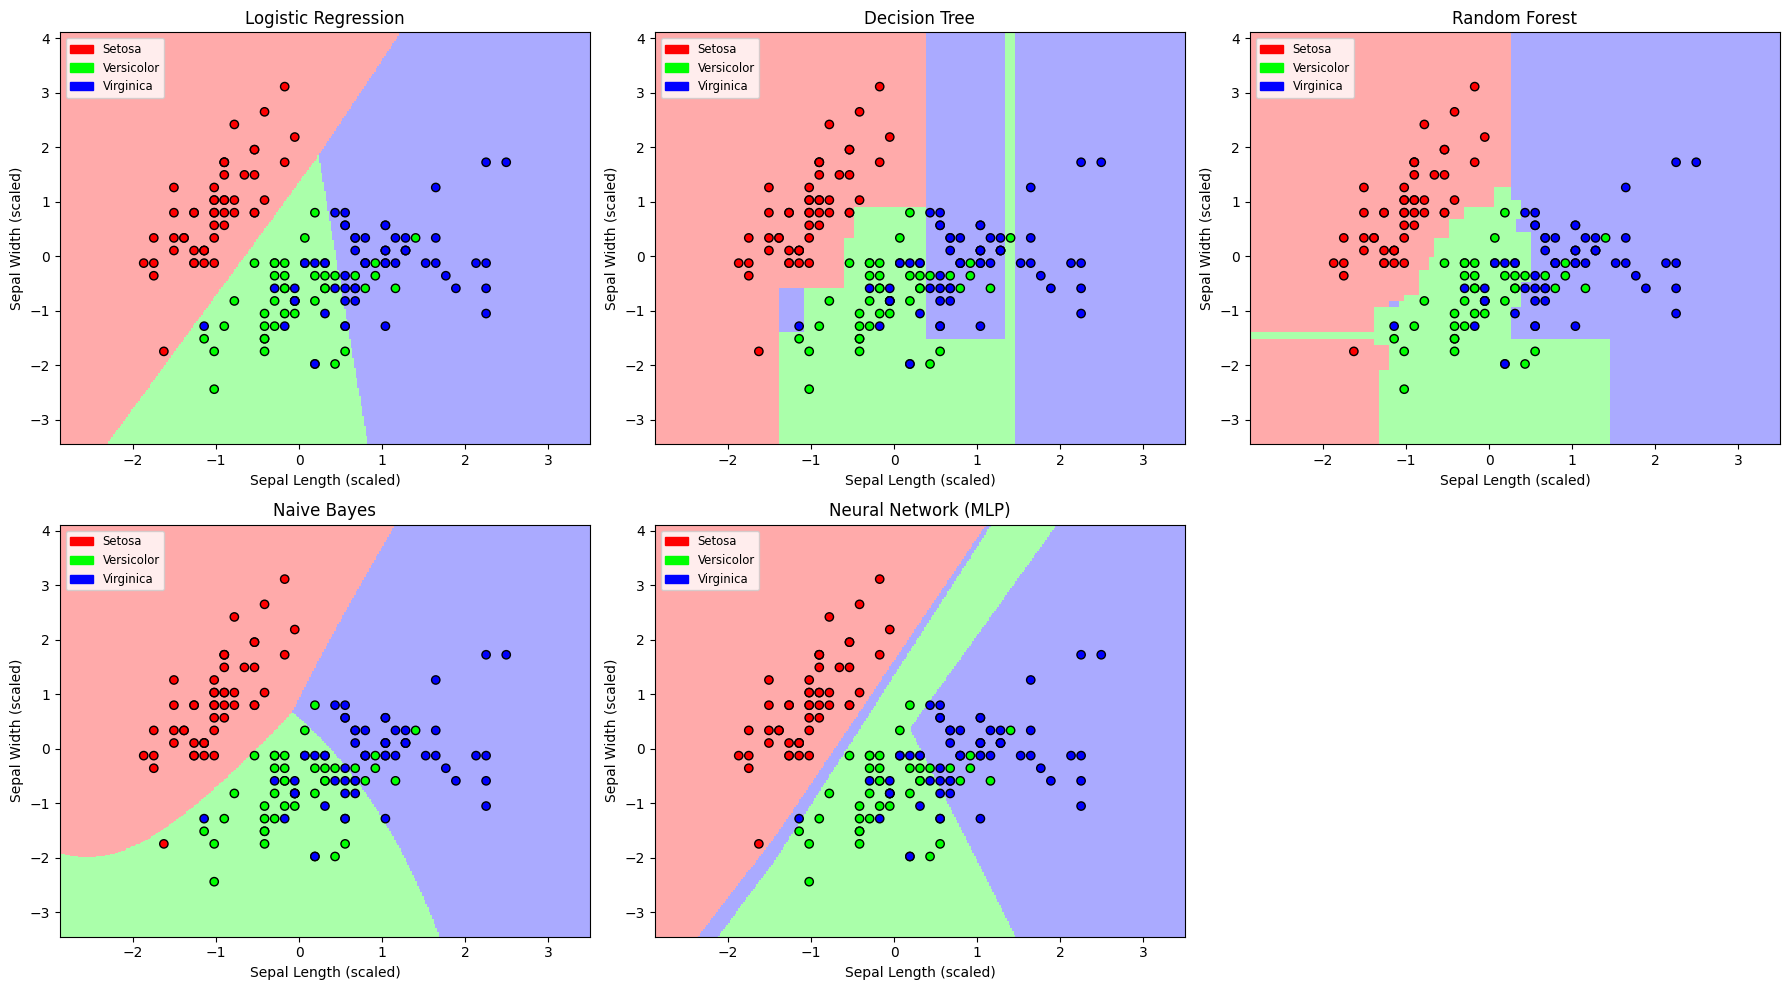

In [ ]:
import matplotlib.patches as mpatches

def plot_decision_boundaries(models, X, y, feature_indices=[0, 1]):
    # Mapping for Iris features and species
    feature_names = {
        0: "Sepal Length (scaled)",
        1: "Sepal Width (scaled)",
        2: "Petal Length (scaled)",
        3: "Petal Width (scaled)"
    }

    # Species names for the legend
    target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

    X_plot = X.iloc[:, feature_indices].values if hasattr(X, 'iloc') else X[:, feature_indices]

    h = .02
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Define standard colors
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF0000', '#00FF00', '#0000FF']

    plt.figure(figsize=(18, 10))

    for i, (name, model) in enumerate(models.items()):
        plt.subplot(2, 3, i + 1)

        clf = model.__class__(**model.get_params())
        clf.fit(X_plot, y)

        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
        plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, edgecolors='k',
                    cmap=ListedColormap(cmap_bold))

        plt.title(f"{name}")
        plt.xlabel(feature_names.get(feature_indices[0], f"Feature {feature_indices[0]}"))
        plt.ylabel(feature_names.get(feature_indices[1], f"Feature {feature_indices[1]}"))

        # --- LEGEND LOGIC START ---
        # Create custom legend handles using the same colors as cmap_bold
        handles = [mpatches.Patch(color=cmap_bold[i], label=target_names[i]) for i in range(3)]
        plt.legend(handles=handles, loc='upper left', framealpha=0.8, fontsize='small')
        # --- LEGEND LOGIC END ---

    plt.tight_layout()
    plt.show()

# Run it
plot_decision_boundaries(models, X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


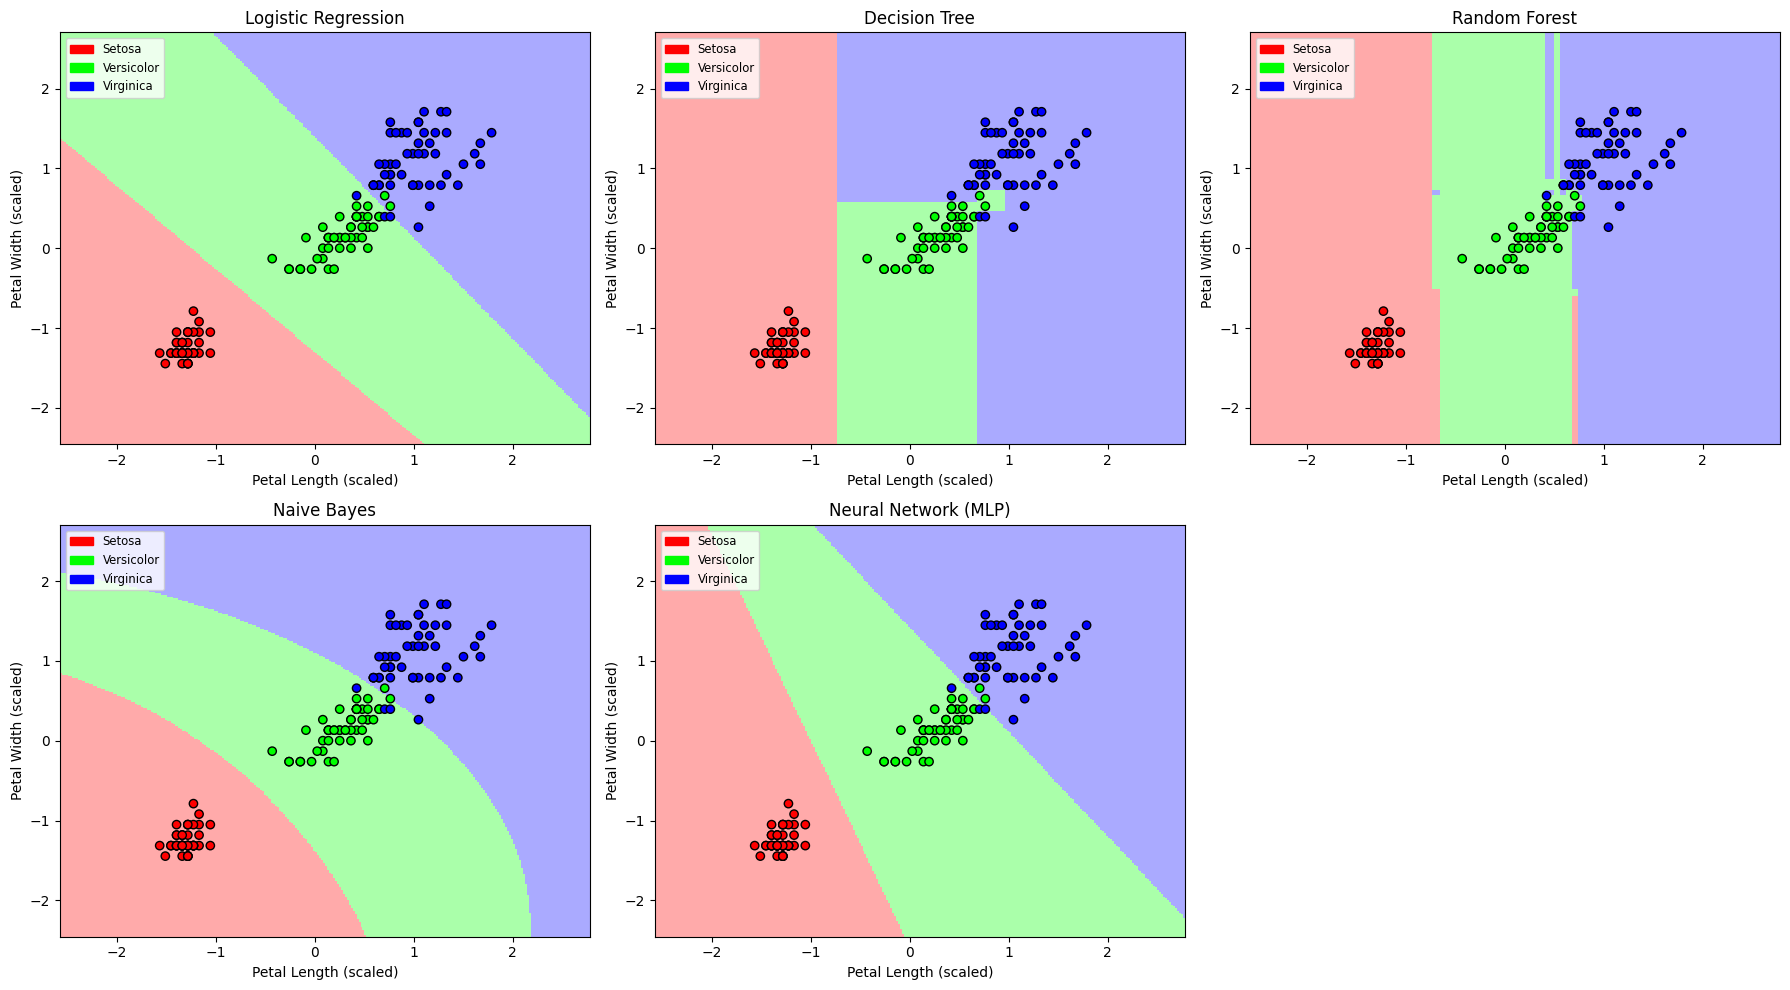

In [ ]:
# [2, 3] selects Petal Length and Petal Width
plot_decision_boundaries(models, X_train_scaled, y_train, feature_indices=[2, 3])

From the boundary visualization plot we can observe that Petal dimensions are more easily distinguishable while sepal dimensions, especially between Versicolor and Virginica, have a significant overlap which makes distiction difficult. Here is some insights into how each model handles this dataset:

+ **Logistic regression** <br>
Linear seperation can be seen clearly in both the sepal and petal plots. The model is able to clearly seperate petal dimensions due to the linear nature of the dimensions. The model also linearly try to seperate based on sepal dimensions, however is less succesful. In a 4D space the model still succeed to achieve up to 97% accuracy in the test set.

+ **Decision Tree** <br>
The decision boundaries for this model are uniquely characterized by axis-aligned, rectangular steps. This reflects the model's hierarchical if else rule-based logic (e.g., "If Petal Length > X"). While it captures the distinct clusters in the petal plot efficiently, the sepal plot shows more complex staircase structures as the model attempts to isolate overlapping data points. This high flexibility can lead to overfitting if the tree depth is not constrained well. During decision tree hyperparameter tuning, the model tend to choose a lower maxDepth which shows overfitting is somewhat managed in this study but could be studied further by utilizing pruning.

+ **Random Forest** <br>
As a model that relies on multiple decision trees, the Random Forest produces a more granular and fragmented boundary compared to a single tree. In the sepal plot, it handles class overlap by creating a boundary that is less erratic than the single Decision Tree. You can see the boundaries in a random forest is more flexible than a single tree. In the petal plot, the model identifies the major clusters with high precision, though it may occasionally create small islands of classification in response to outliers.

+ **Naive Bayes** <br>
This model produces smooth, organic curves based on Gaussian probability distributions. Unlike linear lines of Logistic Regression, Naive Bayes creates boundaries where the statistical likelihood of one species becomes higher than another. It is particularly effective at identifying the center of each species cluster. The curved boundaries in the petal plot illustrate its ability to model the natural variance of the flower measurements without assuming a strictly linear relationship. However, the model fails to capture the overlap between Versicolor and Virginica, most likely because the model assumes independence of each dataset which is not true due to the high overlap between the 2 flower species.

+ **Neural Network (MLP)** <br>
The Multilayer Perceptron demonstrates the most adaptive boundary geometry. In the sepal plot, it creates a corridor for the Virginica species in between Setosa and Versicolor showing a sophisticated ability to find paths through overlapping data that linear models cannot. In the petal space, it produces clean, smooth transitions, demonstrating that it can simplify its complexity when the data is clearly separated. The model visualization show that the potential of further tuning MLP model is high however, the model does take more computing resources and therefore was not chosen as the best model for a simple dataset like the classic iris data.


## 🏁 7. Conclusion

### 7.1 Summary of Experimental Results
This project successfully demonstrated the application of **Spark MLlib** on a **YARN-managed Hadoop cluster** to classify the Iris dataset. Through distributed hyperparameter tuning, four out of five models exceeded the initial 90% accuracy goal. **Logistic Regression** achieved the highest performance with **97.22% accuracy** followed by Random Forest and Neural Network (MLP) which both converged at a stable 94.44% accuracy. Decision Tree provided a respectable baseline at 91.67% accuracy while Naive Bayes proved unsuitable for this specific feature set, resulting in an accuracy of just 66.67%.

### 7.2 Final Recommendation
Based on the performance metrics and computational efficiency, **Logistic Regression** is the recommended model for deployment for this specific IRIS dataset.

### **Justification for Selection:**
1.  **Superior Accuracy:** It provided the highest predictive precision and F1-score (**0.9733**) on the test set.
2.  **Computational Efficiency:** The model reached peak performance with minimal memory and CPU overhead compared to the Multi-Layer Perceptron or the Random Forest ensemble.
3.  **Model Interpretability:** Logistic Regression offers clear coefficients for petal and sepal features, allowing for easier validation of the botanical logic behind each classification.
4.  **Resilience:** By tuning the `regParam` to **0.001**, a highly accurate model was created that remains resistant to overfitting on small datasets.

### 7.3 Final Verdict
The experiment confirms that while advanced models like Neural Networks are powerful, the **linear separability** of the Iris dataset features makes an optimized **Logistic Regression** model the most effective choice for this specific implementation on IRIS dataset. This study highlights the importance of matching algorithm complexity to the nature of the data, ensuring a balance between high accuracy and system scalability within a Big Data environment. The simplicity of logistic regression model meant that incrementally and iteratively changing the parameters is possible within a virtual hadoop environment, to do the same in neural network or random forest is more challenging with the limited computing power this study utilized.

Nevertheless logistic regression selection aligns with the **"No Free Lunch Theorem"** in machine learning, which states that no single model is universally superior for every problem, and the best results are achieved by choosing the algorithm that best fits the specific structure of the data at hand **(Wolpert & Macready, 1997)**. Further investigation into pruning for decision trees is possible; however, for this study, optimization was more easier achieved with logistic regression, as its initial coefficients already demonstrated superior performance compared to the decision tree method.

---


# 📚 References

*   **Apache Software Foundation.** (2023). *Machine Learning Library (MLlib) Guide*. Apache Spark Documentation. https://spark.apache.org/docs/latest/ml-guide.html
*   **Breiman, L.** (2001). Random Forests. *Machine Learning*, 45(1), 5-32. https://doi.org/10.1023/A:1010933404324
*   **Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J.** (1984). *Classification and Regression Trees*. Wadsworth & Brooks.
*   **Fisher, R. A.** (1936). The Use of Multiple Measurements in Taxonomic Problems. *Annals of Eugenics*, 7(2), 179-188. (Original Iris Dataset Source).
*   **Haykin, S. S.** (2009). *Neural Networks and Learning Machines* (3rd ed.). Pearson Education.
*   **Wolpert, D. H., & Macready, W. G.** (1997). No Free Lunch Theorems for Optimization. *IEEE Transactions on Evolutionary Computation*, 1(1), 67-82.
*   **Zaharia, M., et al.** (2016). Apache Spark: A Unified Engine for Big Data Processing. *Communications of the ACM*, 59(11), 56-65.
*   **Zhang, H.** (2004). The Optimality of Naive Bayes. *Proceedings of the Seventeenth International Florida Artificial Intelligence Research Society Conference*.

